In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# ETL

In [72]:
url_data_cadastral = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds-junior/master/data/base_cadastral.csv"
url_data_info = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds-junior/master/data/base_info.csv"
url_data_pagamentos_desenvolvimento = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds-junior/master/data/base_pagamentos_desenvolvimento.csv"
url_data_pagamentos_teste = "https://raw.githubusercontent.com/datarisk-io/datarisk-case-ds-junior/master/data/base_pagamentos_teste.csv"

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

df_dc = pd.read_csv(url_data_cadastral, sep=';')
df_di = pd.read_csv(url_data_info, sep=';')
df_dpd = pd.read_csv(url_data_pagamentos_desenvolvimento, sep=';')
df_dpt = pd.read_csv(url_data_pagamentos_teste, sep=';')

bases = {
    'Cadastral': df_dc,
    'Info': df_di,
    'Pag. Desenvolvimento': df_dpd,
    'Pag. Teste': df_dpt
}

In [73]:
df_dc.head()

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


In [74]:
df_dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_CLIENTE           1315 non-null   int64 
 1   DATA_CADASTRO        1315 non-null   object
 2   DDD                  1078 non-null   object
 3   FLAG_PF              66 non-null     object
 4   SEGMENTO_INDUSTRIAL  1232 non-null   object
 5   DOMINIO_EMAIL        1285 non-null   object
 6   PORTE                1274 non-null   object
 7   CEP_2_DIG            1315 non-null   object
dtypes: int64(1), object(7)
memory usage: 82.3+ KB


In [75]:
df_di.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  object 
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 762.7+ KB


In [76]:
df_dpd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  object 
 3   DATA_PAGAMENTO          77414 non-null  object 
 4   DATA_VENCIMENTO         77414 non-null  object 
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.1+ MB


In [77]:
df_dpt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  object 
 3   DATA_VENCIMENTO         12275 non-null  object 
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 575.5+ KB


In [78]:
for nome, df in bases.items():
    print(f"{'='*50}")
    print(f"{nome} → {df.shape[0]:,} linhas | {df.shape[1]} colunas")
    nulos = df.isnull().sum()
    nulos_pct = (nulos / len(df) * 100).round(1)
    resumo = pd.DataFrame({'nulos': nulos, '%': nulos_pct})
    print(resumo[resumo['nulos'] > 0])
    print()

Cadastral → 1,315 linhas | 8 colunas
                     nulos     %
DDD                    237 18.00
FLAG_PF               1249 95.00
SEGMENTO_INDUSTRIAL     83  6.30
DOMINIO_EMAIL           30  2.30
PORTE                   41  3.10

Info → 24,401 linhas | 4 colunas
                    nulos    %
RENDA_MES_ANTERIOR    717 2.90
NO_FUNCIONARIOS      1252 5.10

Pag. Desenvolvimento → 77,414 linhas | 7 colunas
               nulos    %
VALOR_A_PAGAR   1170 1.50

Pag. Teste → 12,275 linhas | 6 colunas
               nulos    %
VALOR_A_PAGAR    131 1.10



In [79]:
print("Valores únicos FLAG_PF:")
print(df_dc['FLAG_PF'].value_counts(dropna=False))

print()

df_dpd['atraso'] = (
    pd.to_datetime(df_dpd['DATA_PAGAMENTO']) -
    pd.to_datetime(df_dpd['DATA_VENCIMENTO'])
).dt.days

mask_valor_nulo = df_dpd['VALOR_A_PAGAR'].isnull()
print(f"Registros com VALOR_A_PAGAR nulo: {mask_valor_nulo.sum()}")
print(f"Taxa de atraso >=5 dias (valor nulo) : {(df_dpd[mask_valor_nulo]['atraso'] >= 5).mean():.2%}")
print(f"Taxa de atraso >=5 dias (valor presente): {(df_dpd[~mask_valor_nulo]['atraso'] >= 5).mean():.2%}")
print()
print("Distribuição do atraso onde valor é nulo:")
print(df_dpd[mask_valor_nulo]['atraso'].describe())

Valores únicos FLAG_PF:
FLAG_PF
NaN    1249
X        66
Name: count, dtype: int64

Registros com VALOR_A_PAGAR nulo: 1170
Taxa de atraso >=5 dias (valor nulo) : 9.40%
Taxa de atraso >=5 dias (valor presente): 6.99%

Distribuição do atraso onde valor é nulo:
count   1170.00
mean      -0.35
std       13.98
min     -176.00
25%        0.00
50%        0.00
75%        0.00
max      117.00
Name: atraso, dtype: float64


In [80]:
df_dc['is_pf'] = (df_dc['FLAG_PF'] == 'X').astype(int)
df_dc['tipo_cliente'] = df_dc['FLAG_PF'].map({'X': 'PF'}).fillna('PJ')

print(df_dc['tipo_cliente'].value_counts(dropna=False))

tipo_cliente
PJ    1249
PF      66
Name: count, dtype: int64


In [81]:
df_dpd['atraso'] = (
    pd.to_datetime(df_dpd['DATA_PAGAMENTO']) -
    pd.to_datetime(df_dpd['DATA_VENCIMENTO'])
).dt.days

df_dpd['INADIMPLENTE'] = (df_dpd['atraso'] >= 5).astype(int)

# Confirmar
print("Target criado:")
print(df_dpd['INADIMPLENTE'].value_counts(normalize=True).round(4))

Target criado:
INADIMPLENTE
0   0.93
1   0.07
Name: proportion, dtype: float64


In [82]:
df_perfil = df_dpd[['ID_CLIENTE', 'INADIMPLENTE']].merge(
    df_dc[['ID_CLIENTE', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'tipo_cliente']],
    on='ID_CLIENTE', how='left'
)

print(df_perfil['tipo_cliente'].value_counts(dropna=False))

tipo_cliente
PJ    77195
PF      219
Name: count, dtype: int64


# EDA

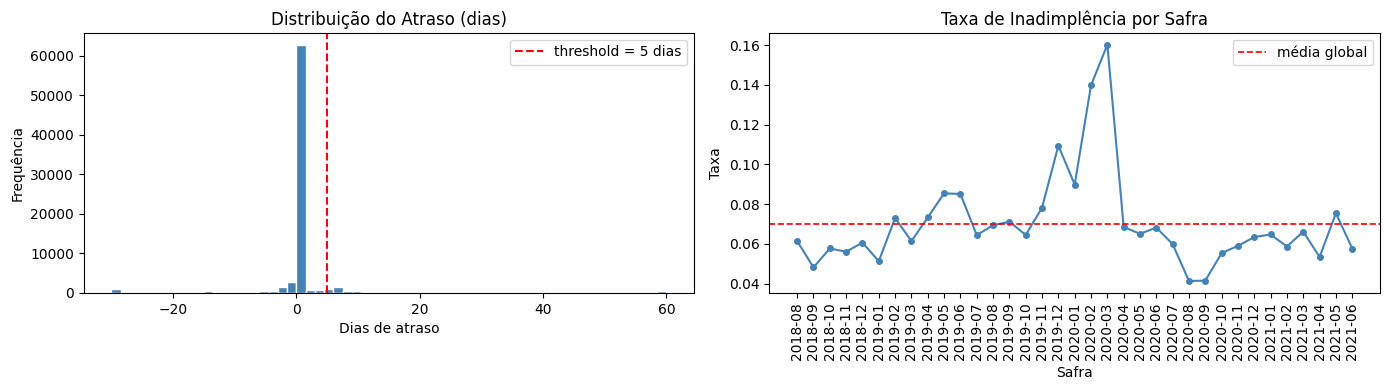

Taxa global de inadimplência: 7.02%

Top 5 safras com maior inadimplência:
   SAFRA_REF  taxa_inad
19   2020-03       0.16
18   2020-02       0.14
16   2019-12       0.11
17   2020-01       0.09
9    2019-05       0.09


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

atraso_zoom = df_dpd['atraso'].clip(-30, 60)
axes[0].hist(atraso_zoom, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(5, color='red', linestyle='--', linewidth=1.5, label='threshold = 5 dias')
axes[0].set_title('Distribuição do Atraso (dias)')
axes[0].set_xlabel('Dias de atraso')
axes[0].set_ylabel('Frequência')
axes[0].legend()

df_dpd['INADIMPLENTE'] = (df_dpd['atraso'] >= 5).astype(int)

inad_safra = (
    df_dpd.groupby('SAFRA_REF')['INADIMPLENTE']
    .mean()
    .reset_index()
    .rename(columns={'INADIMPLENTE': 'taxa_inad'})
)

axes[1].plot(inad_safra['SAFRA_REF'], inad_safra['taxa_inad'],
             marker='o', markersize=4, color='steelblue')
axes[1].axhline(inad_safra['taxa_inad'].mean(),
                color='red', linestyle='--', linewidth=1.2, label='média global')
axes[1].set_title('Taxa de Inadimplência por Safra')
axes[1].set_xlabel('Safra')
axes[1].set_ylabel('Taxa')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Taxa global de inadimplência: {df_dpd['INADIMPLENTE'].mean():.2%}")
print(f"\nTop 5 safras com maior inadimplência:")
print(inad_safra.sort_values('taxa_inad', ascending=False).head())

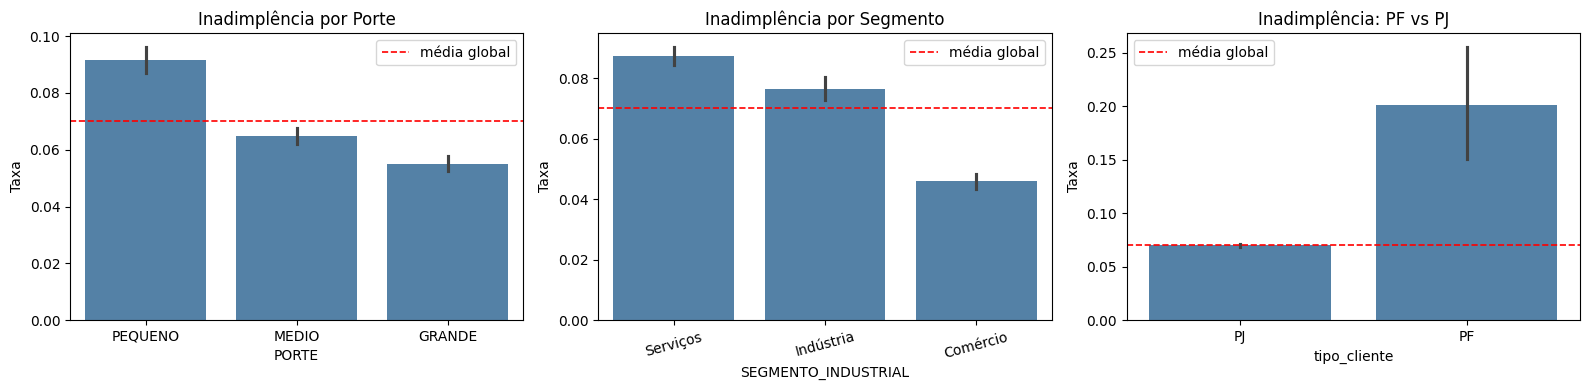

In [85]:
df_perfil = df_dpd[['ID_CLIENTE', 'INADIMPLENTE']].merge(
    df_dc[['ID_CLIENTE', 'PORTE', 'SEGMENTO_INDUSTRIAL', 'tipo_cliente']],
    on='ID_CLIENTE', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
media_global = df_dpd['INADIMPLENTE'].mean()

ordem_porte = (df_perfil.groupby('PORTE')['INADIMPLENTE']
               .mean().sort_values(ascending=False).index)
sns.barplot(data=df_perfil, x='PORTE', y='INADIMPLENTE',
            order=ordem_porte, ax=axes[0], color='steelblue')
axes[0].axhline(media_global, color='red', linestyle='--', linewidth=1.2, label='média global')
axes[0].set_title('Inadimplência por Porte')
axes[0].set_ylabel('Taxa')
axes[0].legend()

ordem_seg = (df_perfil.groupby('SEGMENTO_INDUSTRIAL')['INADIMPLENTE']
             .mean().sort_values(ascending=False).index)
sns.barplot(data=df_perfil, x='SEGMENTO_INDUSTRIAL', y='INADIMPLENTE',
            order=ordem_seg, ax=axes[1], color='steelblue')
axes[1].axhline(media_global, color='red', linestyle='--', linewidth=1.2, label='média global')
axes[1].set_title('Inadimplência por Segmento')
axes[1].set_ylabel('Taxa')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

sns.barplot(data=df_perfil, x='tipo_cliente', y='INADIMPLENTE',
            ax=axes[2], color='steelblue')
axes[2].axhline(media_global, color='red', linestyle='--', linewidth=1.2, label='média global')
axes[2].set_title('Inadimplência: PF vs PJ')
axes[2].set_ylabel('Taxa')
axes[2].legend()

plt.tight_layout()
plt.show()

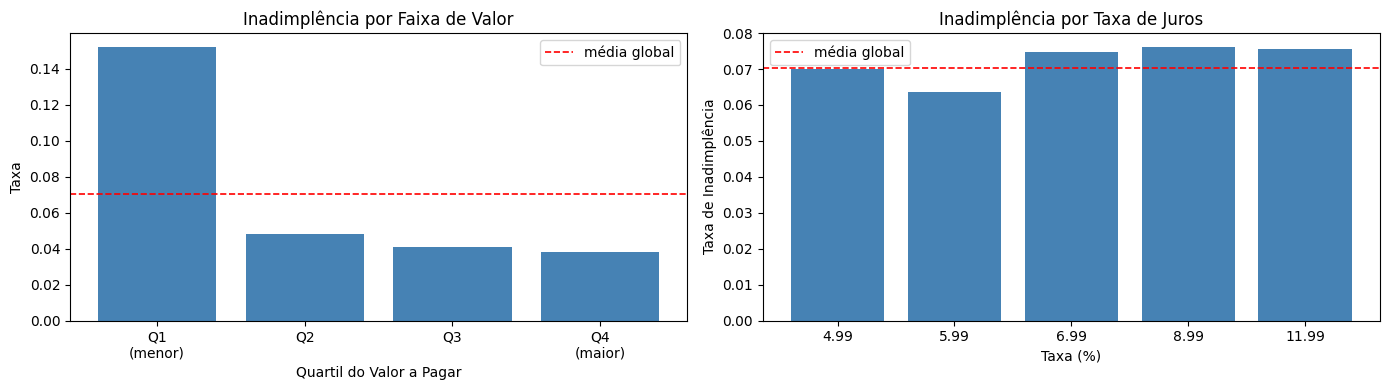

--- Por faixa de valor ---
             taxa      n
faixa_valor             
Q1\n(menor)  0.15  19061
Q2           0.05  19061
Q3           0.04  19061
Q4\n(maior)  0.04  19061

--- Por faixa de taxa ---
   TAXA  taxa_inad      n
0  4.99       0.07  15703
1  5.99       0.06  26459
2  6.99       0.07  22021
3  8.99       0.08   7934
4 11.99       0.08   5297


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_dpd['faixa_valor'] = pd.qcut(
    df_dpd['VALOR_A_PAGAR'], q=4,
    labels=['Q1\n(menor)', 'Q2', 'Q3', 'Q4\n(maior)']
)

inad_valor = (df_dpd.groupby('faixa_valor', observed=True)['INADIMPLENTE']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'taxa', 'count': 'n'}))

axes[0].bar(inad_valor.index, inad_valor['taxa'], color='steelblue')
axes[0].axhline(df_dpd['INADIMPLENTE'].mean(), color='red',
                linestyle='--', linewidth=1.2, label='média global')
axes[0].set_title('Inadimplência por Faixa de Valor')
axes[0].set_ylabel('Taxa')
axes[0].set_xlabel('Quartil do Valor a Pagar')
axes[0].legend()

inad_taxa = (df_dpd.groupby('TAXA')['INADIMPLENTE']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'taxa_inad', 'count': 'n'})
             .reset_index())

axes[1].bar(inad_taxa['TAXA'].astype(str), inad_taxa['taxa_inad'], color='steelblue')
axes[1].axhline(df_dpd['INADIMPLENTE'].mean(), color='red',
                linestyle='--', linewidth=1.2, label='média global')
axes[1].set_title('Inadimplência por Taxa de Juros')
axes[1].set_ylabel('Taxa de Inadimplência')
axes[1].set_xlabel('Taxa (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("--- Por faixa de valor ---")
print(inad_valor.round(4))
print("\n--- Por faixa de taxa ---")
print(inad_taxa.round(4))

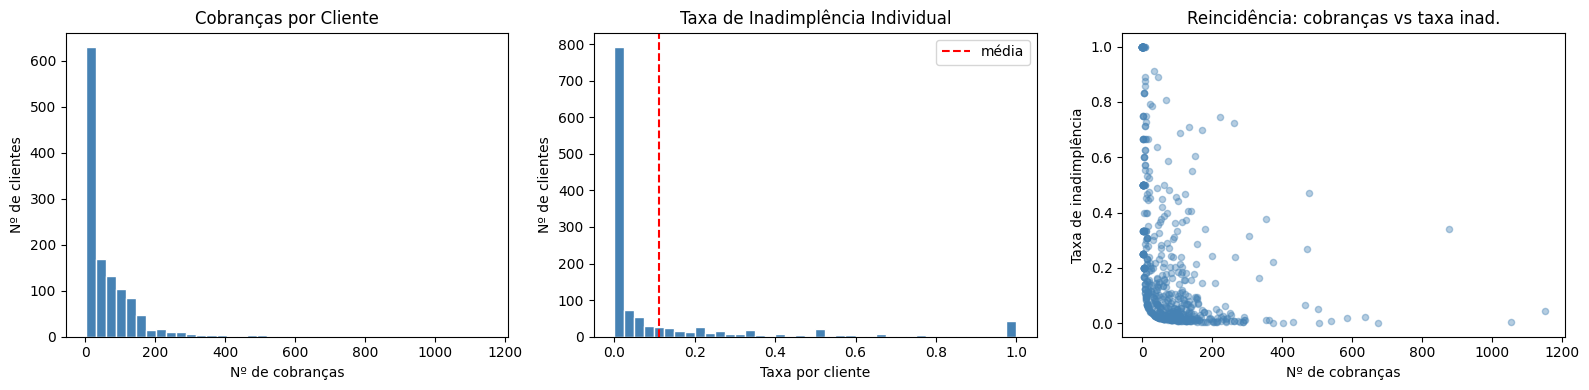

Clientes com pelo menos 1 inadimplência: 597 (47.8% do total)
Clientes com tx_inad > 20%: 211

Estatísticas de cobranças por cliente:
count   1248.00
mean      62.00
std       94.40
min        1.00
25%        5.00
50%       28.00
75%       90.00
max     1151.00
Name: n_cobranças, dtype: float64


In [93]:
cobr_por_cliente = df_dpd.groupby('ID_CLIENTE').agg(
    n_cobranças=('INADIMPLENTE', 'count'),
    n_safras=('SAFRA_REF', 'nunique'),
    tx_inad=('INADIMPLENTE', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(cobr_por_cliente['n_cobranças'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Cobranças por Cliente')
axes[0].set_xlabel('Nº de cobranças')
axes[0].set_ylabel('Nº de clientes')

axes[1].hist(cobr_por_cliente['tx_inad'], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(cobr_por_cliente['tx_inad'].mean(), color='red',
                linestyle='--', linewidth=1.5, label='média')
axes[1].set_title('Taxa de Inadimplência Individual')
axes[1].set_xlabel('Taxa por cliente')
axes[1].set_ylabel('Nº de clientes')
axes[1].legend()

reincidentes = cobr_por_cliente[cobr_por_cliente['tx_inad'] > 0]
axes[2].scatter(reincidentes['n_cobranças'], reincidentes['tx_inad'],
                alpha=0.4, color='steelblue', s=20)
axes[2].set_title('Reincidência: cobranças vs taxa inad.')
axes[2].set_xlabel('Nº de cobranças')
axes[2].set_ylabel('Taxa de inadimplência')

plt.tight_layout()
plt.show()

print(f"Clientes com pelo menos 1 inadimplência: {(cobr_por_cliente['tx_inad'] > 0).sum()} "
      f"({(cobr_por_cliente['tx_inad'] > 0).mean():.1%} do total)")
print(f"Clientes com tx_inad > 20%: {(cobr_por_cliente['tx_inad'] > 0.2).sum()}")
print(f"\nEstatísticas de cobranças por cliente:")
print(cobr_por_cliente['n_cobranças'].describe().round(1))

## Resumo da EDA — Principais Achados

### Target
- Taxa global de inadimplência de **7%** — dataset desbalanceado, classes majoritariamente adimplentes
- Definição aplicada: pagamento com **5 ou mais dias de atraso** em relação ao vencimento
- Distribuição do atraso fortemente concentrada em zero — a maioria paga exatamente no dia

### Comportamento Temporal
- Pico expressivo de inadimplência em **fev-mar/2020 (~14-16%)**, coincidindo com o início da pandemia de COVID-19
- Após o choque, a taxa retornou rapidamente à média histórica (~7%)
- A base de teste cobre **jul-nov/2021** — cenário pós-pandemia, mais estável

### Valor e Taxa
- **Relação inversa entre valor e inadimplência**: cobranças menores (Q1) têm taxa de 15%, quase 4x maior que os demais quartis (~4-5%)
  - Hipótese: clientes priorizam pagamentos grandes para evitar juros acumulados
- **Taxa de juros** tem sinal fraco mas coerente: taxas maiores associadas a inadimplência levemente maior
  - Variação pequena (6% a 8%) — feature de menor impacto esperado no modelo

### Perfil do Cliente
- **Porte**: relação inversa clara — PEQUENO (9%) > MEDIO (6.5%) > GRANDE (5.5%)
  - Empresas menores têm menos reserva financeira para honrar compromissos
- **Segmento**: Serviços (8.5%) e Indústria (7.5%) acima da média; Comércio (4.5%) bem abaixo
  - Comércio tem fluxo de caixa mais previsível e recorrente
- **PF vs PJ**: pessoas físicas inadimplem ~3x mais (20% vs 7%)
  - Amostra pequena (219 cobranças PF) — intervalo de confiança largo, mas sinal relevante

### Comportamento Histórico Individual
- **70% dos clientes nunca inadimpliram** — histórico individual é o sinal mais forte disponível
- Apenas 30% tiveram ao menos 1 atraso; clientes com taxa > 20% são 88 no total
- Clientes com poucas cobranças têm taxas individuais voláteis (ex: 1 cobrança = 0% ou 100%)
  - Features históricas precisarão considerar o **volume de histórico** para ser confiáveis

### Qualidade dos Dados
- `VALOR_A_PAGAR` nulo em 1.5% dos registros — inadimplência nesses casos é 9.4% vs 7% nos demais, sinal que não deve ser descartado
- `FLAG_PF` com 95% nulos confirmados como PJ (têm PORTE e SEGMENTO preenchidos)
- Variáveis cadastrais com nulos pequenos (< 7%) — tratar como categoria `DESCONHECIDO`

# FEATURE ENGINEERING


## Estratégias contra Overfitting e Viés

### 1. Data Leakage
Risco mais crítico do projeto. Toda feature histórica é calculada com `shift(1)`,
garantindo que apenas safras **anteriores** à safra atual sejam usadas.
O merge com `base_info` respeita a safra de referência — nunca usa dados do mês corrente.

### 2. Overfitting
Validação **Out-of-Time (OOT)**: treino em safras passadas, validação em safras recentes.
Split aleatório seria incorreto em séries temporais financeiras.
Features históricas são ponderadas pelo volume — taxa de 50% com 2 cobranças
é muito menos confiável que 50% com 100 cobranças.

### 3. Target Leakage
Nenhuma feature é derivada de `DATA_PAGAMENTO` ou `atraso_dias` da safra atual —
essas colunas só existem depois que o evento acontece.

### 4. Viés Temporal
Fev-mar/2020 são outliers claros (COVID). O modelo é avaliado em diferentes
janelas de tempo para garantir que não aprendeu padrões específicos desse período.

### 5. Desbalanceamento
Dataset com 7% de inadimplentes. Métricas usadas: **AUC-ROC** e **KS** —
nunca acurácia. LightGBM configurado com `is_unbalance=True`.

### Decisões Centrais

| Decisão | Abordagem |
|---|---|
| Split | Out-of-Time — treino até safra X, validação nas safras seguintes |
| Features históricas | `shift(1)` — apenas safras anteriores à atual |
| Avaliação | AUC-ROC + KS + calibração por decil |

In [94]:
df_dpd = df_dpd.sort_values(['ID_CLIENTE', 'SAFRA_REF']).reset_index(drop=True)

hist = (df_dpd.groupby(['ID_CLIENTE', 'SAFRA_REF'])
        .agg(
            inad_safra=('INADIMPLENTE', 'mean'),
            n_cobr_safra=('INADIMPLENTE', 'count')
        )
        .reset_index()
        .sort_values(['ID_CLIENTE', 'SAFRA_REF']))

def features_historicas(grupo):
    grupo = grupo.copy()

    grupo['hist_tx_inad']     = grupo['inad_safra'].shift(1).expanding().mean()
    grupo['hist_n_inad']      = grupo['inad_safra'].shift(1).expanding().sum()
    grupo['hist_n_safras']    = grupo['inad_safra'].shift(1).expanding().count()

    grupo['hist_inad_ult3m']  = grupo['inad_safra'].shift(1).rolling(3, min_periods=1).mean()

    grupo['hist_inad_ult6m']  = grupo['inad_safra'].shift(1).rolling(6, min_periods=1).mean()

    return grupo

feat_hist = (hist.groupby('ID_CLIENTE', group_keys=False)
             .apply(features_historicas)
             [['ID_CLIENTE', 'SAFRA_REF', 'hist_tx_inad',
               'hist_n_inad', 'hist_n_safras',
               'hist_inad_ult3m', 'hist_inad_ult6m']])

print(feat_hist.shape)
print(feat_hist.head(10).to_string())

(21121, 7)
         ID_CLIENTE SAFRA_REF  hist_tx_inad  hist_n_inad  hist_n_safras  hist_inad_ult3m  hist_inad_ult6m
0  8784237149961904   2018-08           NaN          NaN           0.00              NaN              NaN
1  8784237149961904   2018-09          0.00         0.00           1.00             0.00             0.00
2  8784237149961904   2018-10          0.00         0.00           2.00             0.00             0.00
3  8784237149961904   2018-11          0.00         0.00           3.00             0.00             0.00
4  8784237149961904   2018-12          0.00         0.00           4.00             0.00             0.00
5  8784237149961904   2019-01          0.00         0.00           5.00             0.00             0.00
6  8784237149961904   2019-02          0.00         0.00           6.00             0.00             0.00
7  8784237149961904   2019-03          0.00         0.00           7.00             0.00             0.00
8  8784237149961904   2019-04      

/tmp/ipykernel_5635/4208313207.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(features_historicas)


In [95]:
# Pegar um cliente que já inadimpliu pelo menos uma vez
cliente_com_inad = (df_dpd[df_dpd['INADIMPLENTE'] == 1]
                    ['ID_CLIENTE'].value_counts().index[0])

print(f"Cliente analisado: {cliente_com_inad}")

print("\n--- Histórico real (df_dpd) ---")
print(df_dpd[df_dpd['ID_CLIENTE'] == cliente_com_inad]
      [['ID_CLIENTE', 'SAFRA_REF', 'INADIMPLENTE']]
      .groupby('SAFRA_REF')['INADIMPLENTE'].mean()
      .reset_index().to_string())

print("\n--- Feature histórica calculada ---")
print(feat_hist[feat_hist['ID_CLIENTE'] == cliente_com_inad]
      .to_string())

Cliente analisado: 4008627434689715639

--- Histórico real (df_dpd) ---
   SAFRA_REF  INADIMPLENTE
0    2018-08          0.00
1    2018-09          0.08
2    2018-10          0.28
3    2018-11          0.09
4    2018-12          0.10
5    2019-01          0.10
6    2019-02          0.15
7    2019-03          0.28
8    2019-04          0.29
9    2019-05          0.40
10   2019-06          0.20
11   2019-07          0.24
12   2019-08          0.10
13   2019-09          0.42
14   2019-10          0.56
15   2019-11          0.78
16   2019-12          0.84
17   2020-01          0.20
18   2020-02          0.15
19   2020-03          0.31
20   2020-04          0.12
21   2020-05          0.38
22   2020-06          0.21
23   2020-07          0.00
24   2020-08          0.15
25   2020-09          0.07
26   2020-10          0.23
27   2020-11          0.57
28   2020-12          0.14
29   2021-01          0.59
30   2021-02          0.09
31   2021-03          0.06
32   2021-04          0.05
33   2021-

In [96]:
# Atraso médio histórico por safra
hist_atraso = (df_dpd.groupby(['ID_CLIENTE', 'SAFRA_REF'])
               .agg(atraso_medio_safra=('atraso', 'mean'))
               .reset_index()
               .sort_values(['ID_CLIENTE', 'SAFRA_REF']))

def features_atraso(grupo):
    grupo = grupo.copy()
    grupo['hist_atraso_medio'] = (grupo['atraso_medio_safra']
                                  .shift(1).expanding().mean())
    grupo['hist_atraso_max']   = (grupo['atraso_medio_safra']
                                  .shift(1).expanding().max())
    return grupo

feat_atraso = (hist_atraso.groupby('ID_CLIENTE', group_keys=False)
               .apply(features_atraso)
               [['ID_CLIENTE', 'SAFRA_REF',
                 'hist_atraso_medio', 'hist_atraso_max']])

# Meses desde a última inadimplência
hist_inad = (df_dpd.groupby(['ID_CLIENTE', 'SAFRA_REF'])['INADIMPLENTE']
             .max()
             .reset_index()
             .sort_values(['ID_CLIENTE', 'SAFRA_REF']))

def meses_desde_inad(grupo):
    grupo = grupo.copy()
    grupo['safra_dt'] = pd.to_datetime(grupo['SAFRA_REF'] + '-01')

    ultima_inad = pd.NaT
    meses = []
    for _, row in grupo.iterrows():
        if pd.isna(ultima_inad):
            meses.append(np.nan)
        else:
            meses.append(
                (row['safra_dt'] - ultima_inad).days / 30
            )
        if row['INADIMPLENTE'] == 1:
            ultima_inad = row['safra_dt']

    grupo['hist_meses_desde_inad'] = meses
    return grupo

feat_recencia = (hist_inad.groupby('ID_CLIENTE', group_keys=False)
                 .apply(meses_desde_inad)
                 [['ID_CLIENTE', 'SAFRA_REF', 'hist_meses_desde_inad']])

feat_hist_completa = (feat_hist
                      .merge(feat_atraso,  on=['ID_CLIENTE', 'SAFRA_REF'], how='left')
                      .merge(feat_recencia, on=['ID_CLIENTE', 'SAFRA_REF'], how='left'))

print(feat_hist_completa.shape)
print(feat_hist_completa.head(3).to_string())

/tmp/ipykernel_5635/130002638.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(features_atraso)


(21121, 10)
         ID_CLIENTE SAFRA_REF  hist_tx_inad  hist_n_inad  hist_n_safras  hist_inad_ult3m  hist_inad_ult6m  hist_atraso_medio  hist_atraso_max  hist_meses_desde_inad
0  8784237149961904   2018-08           NaN          NaN           0.00              NaN              NaN                NaN              NaN                    NaN
1  8784237149961904   2018-09          0.00         0.00           1.00             0.00             0.00              -0.40            -0.40                    NaN
2  8784237149961904   2018-10          0.00         0.00           2.00             0.00             0.00              -0.20             0.00                    NaN


/tmp/ipykernel_5635/130002638.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(meses_desde_inad)


In [97]:
# Features da cobrança atual
df_dpd['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(df_dpd['DATA_EMISSAO_DOCUMENTO'])
df_dpd['DATA_VENCIMENTO']        = pd.to_datetime(df_dpd['DATA_VENCIMENTO'])

# Prazo entre emissão e vencimento
df_dpd['prazo_dias'] = (df_dpd['DATA_VENCIMENTO'] -
                         df_dpd['DATA_EMISSAO_DOCUMENTO']).dt.days

# Mês e dia do vencimento — capturam sazonalidade
df_dpd['mes_vencimento'] = df_dpd['DATA_VENCIMENTO'].dt.month
df_dpd['dia_vencimento'] = df_dpd['DATA_VENCIMENTO'].dt.day

df_dpd['log_valor'] = np.log1p(df_dpd['VALOR_A_PAGAR'].fillna(0))

df_dpd['flag_valor_nulo'] = df_dpd['VALOR_A_PAGAR'].isnull().astype(int)

# Safra como inteiro — captura tendência temporal
df_dpd['safra_int'] = pd.to_datetime(df_dpd['SAFRA_REF'] + '-01').dt.to_period('M').astype(int)

print("Features criadas:")
print(df_dpd[['prazo_dias','mes_vencimento','dia_vencimento',
              'log_valor','flag_valor_nulo','safra_int']].describe())

Features criadas:
       prazo_dias  mes_vencimento  dia_vencimento  log_valor  flag_valor_nulo  \
count    77414.00        77414.00        77414.00   77414.00         77414.00   
mean        23.32            6.47           15.35      10.17             0.02   
std         26.14            3.53            8.71       1.68             0.12   
min       -420.00            1.00            1.00       0.00             0.00   
25%         16.00            3.00            8.00       9.82             0.00   
50%         18.00            6.00           15.00      10.44             0.00   
75%         24.00           10.00           23.00      11.01             0.00   
max       2677.00           12.00           31.00      15.30             1.00   

       safra_int  
count   77414.00  
mean      600.61  
std         9.96  
min       583.00  
25%       592.00  
50%       600.00  
75%       609.00  
max       617.00  


In [98]:
# Investigar prazos anômalos
print("Distribuição de prazos negativos:")
print(df_dpd[df_dpd['prazo_dias'] < 0]['prazo_dias'].describe())
print(f"\nQuantidade: {(df_dpd['prazo_dias'] < 0).sum()}")
print(f"% do total: {(df_dpd['prazo_dias'] < 0).mean():.2%}")

print("\nTaxa de inadimplência:")
print(f"  prazo negativo : {df_dpd[df_dpd['prazo_dias'] < 0]['INADIMPLENTE'].mean():.2%}")
print(f"  prazo normal   : {df_dpd[df_dpd['prazo_dias'] >= 0]['INADIMPLENTE'].mean():.2%}")

print("\nExemplos de registros com prazo negativo:")
print(df_dpd[df_dpd['prazo_dias'] < 0]
      [['DATA_EMISSAO_DOCUMENTO','DATA_VENCIMENTO','prazo_dias','INADIMPLENTE']]
      .head(5).to_string())

Distribuição de prazos negativos:
count     27.00
mean     -87.07
std      114.71
min     -420.00
25%     -108.50
50%      -32.00
75%       -9.00
max       -1.00
Name: prazo_dias, dtype: float64

Quantidade: 27
% do total: 0.03%

Taxa de inadimplência:
  prazo negativo : 96.30%
  prazo normal   : 6.99%

Exemplos de registros com prazo negativo:
     DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  prazo_dias  INADIMPLENTE
4808             2021-02-01      2021-01-20         -12             1
4809             2021-02-04      2021-01-31          -4             1
4810             2021-02-04      2021-01-31          -4             1
5211             2019-05-13      2019-01-23        -110             1
5212             2019-05-13      2019-01-23        -110             1


In [99]:
# Flag para prazo anômalo — não dropar, o sinal é forte
df_dpd['flag_prazo_negativo'] = (df_dpd['prazo_dias'] < 0).astype(int)

print("Percentis do prazo_dias (positivos):")
positivos = df_dpd[df_dpd['prazo_dias'] >= 0]['prazo_dias']
print(positivos.quantile([0.9, 0.95, 0.99, 0.999]).round(1))

Percentis do prazo_dias (positivos):
0.90    35.00
0.95    45.00
0.99    93.00
1.00   199.00
Name: prazo_dias, dtype: float64


In [100]:
print("Máximo prazo positivo:")
print(df_dpd[df_dpd['prazo_dias'] >= 0]['prazo_dias'].max())

print("\nQuantos registros com prazo > 200 dias?")
print((df_dpd['prazo_dias'] > 200).sum())

print("\nTaxa de inadimplência prazo > 90 dias:")
print(df_dpd[df_dpd['prazo_dias'] > 90]['INADIMPLENTE'].mean().round(4))

Máximo prazo positivo:
2677

Quantos registros com prazo > 200 dias?
66

Taxa de inadimplência prazo > 90 dias:
0.1955


In [101]:
# Flag para prazo anômalo longo
df_dpd['flag_prazo_longo'] = (df_dpd['prazo_dias'] > 200).astype(int)

df_dpd['prazo_dias_adj'] = df_dpd['prazo_dias'].clip(0, 200)

print("Flags de anomalia criadas:")
print(f"  flag_prazo_negativo : {df_dpd['flag_prazo_negativo'].sum()} registros")
print(f"  flag_prazo_longo    : {df_dpd['flag_prazo_longo'].sum()} registros")
print(f"  flag_valor_nulo     : {df_dpd['flag_valor_nulo'].sum()} registros")

print("\nTaxa de inadimplência por flag:")
for flag in ['flag_prazo_negativo', 'flag_prazo_longo', 'flag_valor_nulo']:
    taxa_sim = df_dpd[df_dpd[flag] == 1]['INADIMPLENTE'].mean()
    taxa_nao = df_dpd[df_dpd[flag] == 0]['INADIMPLENTE'].mean()
    print(f"  {flag}: sim={taxa_sim:.2%} | não={taxa_nao:.2%}")

Flags de anomalia criadas:
  flag_prazo_negativo : 27 registros
  flag_prazo_longo    : 66 registros
  flag_valor_nulo     : 1170 registros

Taxa de inadimplência por flag:
  flag_prazo_negativo: sim=96.30% | não=6.99%
  flag_prazo_longo: sim=43.94% | não=6.99%
  flag_valor_nulo: sim=9.40% | não=6.99%


In [103]:
df_dc['DATA_CADASTRO'] = pd.to_datetime(df_dc['DATA_CADASTRO'])

# Tempo de relacionamento em dias até a safra de referência

for col in ['SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'DDD']:
    df_dc[col] = df_dc[col].fillna('DESCONHECIDO')

print("Nulos restantes no df_dc:")
print(df_dc.isnull().sum())

print("\nDistribuição PORTE:")
print(df_dc['PORTE'].value_counts())

print("\nDistribuição SEGMENTO_INDUSTRIAL:")
print(df_dc['SEGMENTO_INDUSTRIAL'].value_counts())

Nulos restantes no df_dc:
ID_CLIENTE                0
DATA_CADASTRO             0
DDD                       0
FLAG_PF                1249
SEGMENTO_INDUSTRIAL       0
DOMINIO_EMAIL             0
PORTE                     0
CEP_2_DIG                 0
is_pf                     0
tipo_cliente              0
dtype: int64

Distribuição PORTE:
PORTE
MEDIO           522
GRANDE          480
PEQUENO         272
DESCONHECIDO     41
Name: count, dtype: int64

Distribuição SEGMENTO_INDUSTRIAL:
SEGMENTO_INDUSTRIAL
Serviços        503
Comércio        431
Indústria       298
DESCONHECIDO     83
Name: count, dtype: int64


In [104]:
mediana_renda = df_di['RENDA_MES_ANTERIOR'].median()
mediana_func  = df_di['NO_FUNCIONARIOS'].median()

print(f"Mediana renda    : {mediana_renda:,.0f}")
print(f"Mediana funcionários: {mediana_func:.0f}")

print(f"\nNulos RENDA_MES_ANTERIOR : {df_di['RENDA_MES_ANTERIOR'].isnull().sum()}")
print(f"Nulos NO_FUNCIONARIOS    : {df_di['NO_FUNCIONARIOS'].isnull().sum()}")

df_di['log_renda'] = np.log1p(df_di['RENDA_MES_ANTERIOR'].fillna(mediana_renda))
df_di['log_func']  = np.log1p(df_di['NO_FUNCIONARIOS'].fillna(mediana_func))

df_di['flag_renda_nula'] = df_di['RENDA_MES_ANTERIOR'].isnull().astype(int)
df_di['flag_func_nula']  = df_di['NO_FUNCIONARIOS'].isnull().astype(int)

print("\nPrimeiras linhas df_di:")
print(df_di.head(3).to_string())

Mediana renda    : 240,998
Mediana funcionários: 118

Nulos RENDA_MES_ANTERIOR : 717
Nulos NO_FUNCIONARIOS    : 1252

Primeiras linhas df_di:
            ID_CLIENTE SAFRA_REF  RENDA_MES_ANTERIOR  NO_FUNCIONARIOS  log_renda  log_func  flag_renda_nula  flag_func_nula
0  1661240395903230676   2018-09            16913.00              NaN       9.74      4.78                0               1
1  8274986328479596038   2018-09           106430.00           141.00      11.58      4.96                0               0
2   345447888460137901   2018-09           707439.00            99.00      13.47      4.61                0               0


In [106]:
# Base principal: pagamentos desenvolvimento
df_model = df_dpd.copy()

# 1. Merge com features históricas (nível safra do cliente)
df_model = df_model.merge(feat_hist_completa, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

# 2. Merge com base_info — incluir RENDA_MES_ANTERIOR para o ratio
df_model = df_model.merge(
    df_di[['ID_CLIENTE', 'SAFRA_REF', 'log_renda', 'log_func',
           'flag_renda_nula', 'flag_func_nula', 'RENDA_MES_ANTERIOR']],
    on=['ID_CLIENTE', 'SAFRA_REF'], how='left'
)

# 3. Merge com cadastral (nível cliente)
df_model = df_model.merge(
    df_dc[['ID_CLIENTE', 'DATA_CADASTRO', 'DDD', 'is_pf',
           'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']],
    on='ID_CLIENTE', how='left'
)

# 4. Tempo de relacionamento
df_model['tempo_relacionamento'] = (
    pd.to_datetime(df_model['SAFRA_REF'] + '-01') - df_model['DATA_CADASTRO']
).dt.days

# 5. Ratio valor / renda
df_model['ratio_valor_renda'] = (
    df_model['VALOR_A_PAGAR'] / (df_model['RENDA_MES_ANTERIOR'] + 1)
)

# 6. Dropar colunas que não entram no modelo
df_model = df_model.drop(columns=['DATA_CADASTRO', 'RENDA_MES_ANTERIOR'])

print(f"Shape final: {df_model.shape}")
print(f"\nNulos por coluna:")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Shape final: (77414, 39)

Nulos por coluna:
VALOR_A_PAGAR             1170
faixa_valor               1170
hist_tx_inad              2295
hist_n_inad               2295
hist_inad_ult3m           2295
hist_inad_ult6m           2295
hist_atraso_medio         2295
hist_atraso_max           2295
hist_meses_desde_inad    43007
log_renda                 3937
log_func                  3937
flag_renda_nula           3937
flag_func_nula            3937
ratio_valor_renda         7204
dtype: int64


In [107]:
# Dropar colunas de EDA que não entram no modelo
df_model = df_model.drop(columns=['faixa_valor'])

# Confirmar colunas finais
print("Colunas do df_model:")
for col in df_model.columns:
    print(f"  {col}")

Colunas do df_model:
  ID_CLIENTE
  SAFRA_REF
  DATA_EMISSAO_DOCUMENTO
  DATA_PAGAMENTO
  DATA_VENCIMENTO
  VALOR_A_PAGAR
  TAXA
  atraso
  INADIMPLENTE
  prazo_dias
  mes_vencimento
  dia_vencimento
  log_valor
  flag_valor_nulo
  safra_int
  flag_prazo_negativo
  flag_prazo_longo
  prazo_dias_adj
  hist_tx_inad
  hist_n_inad
  hist_n_safras
  hist_inad_ult3m
  hist_inad_ult6m
  hist_atraso_medio
  hist_atraso_max
  hist_meses_desde_inad
  log_renda
  log_func
  flag_renda_nula
  flag_func_nula
  DDD
  is_pf
  SEGMENTO_INDUSTRIAL
  DOMINIO_EMAIL
  PORTE
  CEP_2_DIG
  tempo_relacionamento
  ratio_valor_renda


In [108]:
COLS_ID = ['ID_CLIENTE', 'SAFRA_REF']

COLS_EXCLUIR = [
    'DATA_EMISSAO_DOCUMENTO',
    'DATA_PAGAMENTO',
    'DATA_VENCIMENTO',
    'atraso',
    'VALOR_A_PAGAR',
    'prazo_dias',
]

TARGET = 'INADIMPLENTE'

FEATURES = [col for col in df_model.columns
            if col not in COLS_ID + COLS_EXCLUIR + [TARGET]]

print(f"Total de features: {len(FEATURES)}")
print("\nFeatures do modelo:")
for f in FEATURES:
    print(f"  {f}")

Total de features: 29

Features do modelo:
  TAXA
  mes_vencimento
  dia_vencimento
  log_valor
  flag_valor_nulo
  safra_int
  flag_prazo_negativo
  flag_prazo_longo
  prazo_dias_adj
  hist_tx_inad
  hist_n_inad
  hist_n_safras
  hist_inad_ult3m
  hist_inad_ult6m
  hist_atraso_medio
  hist_atraso_max
  hist_meses_desde_inad
  log_renda
  log_func
  flag_renda_nula
  flag_func_nula
  DDD
  is_pf
  SEGMENTO_INDUSTRIAL
  DOMINIO_EMAIL
  PORTE
  CEP_2_DIG
  tempo_relacionamento
  ratio_valor_renda


## Feature Engineering

### Variáveis criadas

#### Cobrança Atual
| Feature | Descrição |
|---|---|
| `prazo_dias_adj` | Dias entre emissão e vencimento, clipado entre 0 e 200 |
| `mes_vencimento` | Mês do vencimento — captura sazonalidade |
| `dia_vencimento` | Dia do vencimento — captura padrões intra-mensais |
| `log_valor` | Log do valor a pagar — reduz efeito de outliers |
| `safra_int` | Safra como inteiro — captura tendência temporal |
| `TAXA` | Taxa de juros da cobrança |

#### Flags de Anomalia
| Feature | Descrição | Taxa de Inadimplência |
|---|---|---|
| `flag_valor_nulo` | VALOR_A_PAGAR ausente | 9.4% vs 7.0% |
| `flag_prazo_negativo` | Vencimento anterior à emissão | 96.3% vs 7.0% |
| `flag_prazo_longo` | Prazo acima de 200 dias | 43.9% vs 7.0% |

#### Histórico do Cliente
Todas calculadas com `shift(1)` — apenas safras **anteriores** à atual, sem leakage.

| Feature | Descrição |
|---|---|
| `hist_tx_inad` | Taxa de inadimplência histórica acumulada |
| `hist_n_inad` | Número absoluto de inadimplências |
| `hist_n_safras` | Quantidade de safras com histórico |
| `hist_inad_ult3m` | Taxa de inadimplência nos últimos 3 meses |
| `hist_inad_ult6m` | Taxa de inadimplência nos últimos 6 meses |
| `hist_atraso_medio` | Atraso médio histórico em dias |
| `hist_atraso_max` | Maior atraso já registrado |
| `hist_meses_desde_inad` | Meses desde a última inadimplência (NaN = nunca atrasou) |

#### Cadastral
| Feature | Descrição |
|---|---|
| `PORTE` | Tamanho da empresa (PEQUENO/MEDIO/GRANDE/DESCONHECIDO) |
| `SEGMENTO_INDUSTRIAL` | Setor de atuação |
| `DOMINIO_EMAIL` | Provedor de e-mail do cadastro |
| `DDD` | DDD do telefone — proxy de região |
| `CEP_2_DIG` | Dois primeiros dígitos do CEP — proxy de região |
| `is_pf` | Flag binária: 1 = Pessoa Física |
| `tempo_relacionamento` | Dias desde o cadastro até a safra de referência |

#### Info Mensal
| Feature | Descrição |
|---|---|
| `log_renda` | Log da renda/faturamento do mês anterior |
| `log_func` | Log do número de funcionários |
| `flag_renda_nula` | Cliente não reportou renda naquele mês |
| `flag_func_nula` | Cliente não reportou funcionários naquele mês |
| `ratio_valor_renda` | Valor da cobrança / renda — esforço financeiro |

### Decisões importantes
- Nulos nas categóricas tratados como categoria `DESCONHECIDO` — o padrão de não informar pode ter sinal preditivo
- `hist_meses_desde_inad` com NaN significa **nunca inadimpliu** — não é dado ausente, é informação
- Colunas originais preservadas — nenhuma coluna raw foi sobrescrita
- Total de features: **29**

# Split Out-of-Time

In [109]:
print("Registros por safra:")
print(df_model.groupby('SAFRA_REF')['INADIMPLENTE']
      .agg(['count','mean'])
      .rename(columns={'count':'n','mean':'taxa_inad'})
      .round(4).to_string())

Registros por safra:
              n  taxa_inad
SAFRA_REF                 
2018-08     992       0.06
2018-09    1992       0.05
2018-10    2096       0.06
2018-11    2122       0.06
2018-12    2059       0.06
2019-01    2299       0.05
2019-02    1971       0.07
2019-03    2247       0.06
2019-04    2058       0.07
2019-05    2317       0.09
2019-06    2231       0.09
2019-07    2343       0.06
2019-08    2291       0.07
2019-09    2373       0.07
2019-10    2464       0.06
2019-11    2377       0.08
2019-12    2448       0.11
2020-01    2414       0.09
2020-02    2210       0.14
2020-03    1984       0.16
2020-04    1780       0.07
2020-05    1904       0.07
2020-06    2052       0.07
2020-07    2287       0.06
2020-08    2249       0.04
2020-09    2382       0.04
2020-10    2402       0.06
2020-11    2471       0.06
2020-12    2332       0.06
2021-01    2393       0.06
2021-02    2146       0.06
2021-03    2326       0.07
2021-04    2358       0.05
2021-05    2531       0.08
2021-06

In [110]:
SAFRA_CORTE = '2021-04'

treino = df_model[df_model['SAFRA_REF'] < SAFRA_CORTE].copy()
valid  = df_model[df_model['SAFRA_REF'] >= SAFRA_CORTE].copy()

X_treino = treino[FEATURES]
y_treino = treino[TARGET]

X_valid  = valid[FEATURES]
y_valid  = valid[TARGET]

print(f"Treino : {X_treino.shape[0]:,} registros | {y_treino.mean():.2%} inadimplência")
print(f"Validação: {X_valid.shape[0]:,} registros | {y_valid.mean():.2%} inadimplência")
print(f"\nSafras treino : {treino['SAFRA_REF'].min()} → {treino['SAFRA_REF'].max()}")
print(f"Safras validação: {valid['SAFRA_REF'].min()} → {valid['SAFRA_REF'].max()}")

Treino : 70,012 registros | 7.10% inadimplência
Validação: 7,402 registros | 6.24% inadimplência

Safras treino : 2018-08 → 2021-03
Safras validação: 2021-04 → 2021-06


## Split Out-of-Time

### Estratégia
Split temporal — nunca aleatório em séries financeiras.
Treinar em safras passadas e validar em safras recentes simula
exatamente o cenário real de produção do modelo.

### Divisão
| Conjunto | Safras | Registros | Taxa Inadimplência |
|---|---|---|---|
| Treino | 2018-08 → 2021-03 | 70.012 | 7.10% |
| Validação OOT | 2021-04 → 2021-06 | 7.402 | 6.24% |

### Por que esse corte?
As 3 últimas safras do desenvolvimento são as mais próximas
da base de teste (jul-nov/2021) — validar nelas representa
melhor o comportamento esperado em produção.

### O que foi evitado
- Split aleatório misturaria safras futuras no treino — data leakage
- Validar em safras do meio do histórico ignoraria a deriva temporal
- Incluir fev-mar/2020 (COVID) apenas no treino reduz o risco de
o modelo aprender um padrão atípico como regra geral

# Preparação da base de teste

In [111]:
df_teste = df_dpt.copy()

# Features da cobrança atual
df_teste['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(df_teste['DATA_EMISSAO_DOCUMENTO'])
df_teste['DATA_VENCIMENTO']        = pd.to_datetime(df_teste['DATA_VENCIMENTO'])

df_teste['prazo_dias']          = (df_teste['DATA_VENCIMENTO'] -
                                    df_teste['DATA_EMISSAO_DOCUMENTO']).dt.days
df_teste['mes_vencimento']      = df_teste['DATA_VENCIMENTO'].dt.month
df_teste['dia_vencimento']      = df_teste['DATA_VENCIMENTO'].dt.day
df_teste['log_valor']           = np.log1p(df_teste['VALOR_A_PAGAR'].fillna(0))
df_teste['flag_valor_nulo']     = df_teste['VALOR_A_PAGAR'].isnull().astype(int)
df_teste['safra_int']           = pd.to_datetime(df_teste['SAFRA_REF'] + '-01').dt.to_period('M').astype(int)
df_teste['flag_prazo_negativo'] = (df_teste['prazo_dias'] < 0).astype(int)
df_teste['flag_prazo_longo']    = (df_teste['prazo_dias'] > 200).astype(int)
df_teste['prazo_dias_adj']      = df_teste['prazo_dias'].clip(0, 200)

# Features históricas — todo df_dpd é passado em relação ao teste
df_teste = df_teste.merge(feat_hist_completa, on=['ID_CLIENTE', 'SAFRA_REF'], how='left')

# Info mensal
df_teste = df_teste.merge(
    df_di[['ID_CLIENTE', 'SAFRA_REF', 'log_renda', 'log_func',
           'flag_renda_nula', 'flag_func_nula', 'RENDA_MES_ANTERIOR']],
    on=['ID_CLIENTE', 'SAFRA_REF'], how='left'
)

# Cadastral
df_teste = df_teste.merge(
    df_dc[['ID_CLIENTE', 'DATA_CADASTRO', 'DDD', 'is_pf',
           'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']],
    on='ID_CLIENTE', how='left'
)

# Tempo de relacionamento e ratio
df_teste['tempo_relacionamento'] = (
    pd.to_datetime(df_teste['SAFRA_REF'] + '-01') - df_teste['DATA_CADASTRO']
).dt.days

df_teste['ratio_valor_renda'] = (
    df_teste['VALOR_A_PAGAR'] / (df_teste['RENDA_MES_ANTERIOR'] + 1)
)

df_teste = df_teste.drop(columns=['DATA_CADASTRO', 'RENDA_MES_ANTERIOR'])

print(f"Shape base teste: {df_teste.shape}")
print(f"\nNulos por coluna:")
print(df_teste.isnull().sum()[df_teste.isnull().sum() > 0])

Shape base teste: (12275, 35)

Nulos por coluna:
VALOR_A_PAGAR              131
hist_tx_inad             12275
hist_n_inad              12275
hist_n_safras            12275
hist_inad_ult3m          12275
hist_inad_ult6m          12275
hist_atraso_medio        12275
hist_atraso_max          12275
hist_meses_desde_inad    12275
log_renda                  414
log_func                   414
flag_renda_nula            414
flag_func_nula             414
DDD                         38
is_pf                       38
SEGMENTO_INDUSTRIAL         38
DOMINIO_EMAIL               38
PORTE                       38
CEP_2_DIG                   38
tempo_relacionamento        38
ratio_valor_renda          854
dtype: int64


In [112]:
print("Safras em feat_hist_completa:")
print(sorted(feat_hist_completa['SAFRA_REF'].unique()))

print("\nSafras em df_teste:")
print(sorted(df_teste['SAFRA_REF'].unique()))

print("\nClientes em feat_hist_completa:", feat_hist_completa['ID_CLIENTE'].nunique())
print("Clientes em df_teste:", df_dpt['ID_CLIENTE'].nunique())
print("Overlap:", len(set(feat_hist_completa['ID_CLIENTE']) & set(df_dpt['ID_CLIENTE'])))

Safras em feat_hist_completa:
['2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04', '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06']

Safras em df_teste:
['2021-07', '2021-08', '2021-09', '2021-10', '2021-11']

Clientes em feat_hist_completa: 1248
Clientes em df_teste: 976
Overlap: 888


In [114]:
ref_data = '2021-07-01'

hist_geral = (df_dpd.groupby('ID_CLIENTE')
              .agg(
                  hist_tx_inad      = ('INADIMPLENTE', 'mean'),
                  hist_n_inad       = ('INADIMPLENTE', 'sum'),
                  hist_n_safras     = ('SAFRA_REF', 'nunique'),
                  hist_atraso_medio = ('atraso', 'mean'),
                  hist_atraso_max   = ('atraso', 'max'),
              )
              .reset_index())

ult3 = (df_dpd[df_dpd['SAFRA_REF'] >= '2021-04']
        .groupby('ID_CLIENTE')['INADIMPLENTE']
        .mean()
        .reset_index()
        .rename(columns={'INADIMPLENTE': 'hist_inad_ult3m'}))

ult6 = (df_dpd[df_dpd['SAFRA_REF'] >= '2021-01']
        .groupby('ID_CLIENTE')['INADIMPLENTE']
        .mean()
        .reset_index()
        .rename(columns={'INADIMPLENTE': 'hist_inad_ult6m'}))

ultima_inad = (df_dpd[df_dpd['INADIMPLENTE'] == 1]
               .groupby('ID_CLIENTE')['SAFRA_REF']
               .max()
               .reset_index()
               .rename(columns={'SAFRA_REF': 'ultima_inad_safra'}))

ultima_inad['hist_meses_desde_inad'] = (
    pd.to_datetime(ref_data) -
    pd.to_datetime(ultima_inad['ultima_inad_safra'] + '-01')
).dt.days / 30

hist_completo = (hist_geral
                 .merge(ult3, on='ID_CLIENTE', how='left')
                 .merge(ult6, on='ID_CLIENTE', how='left')
                 .merge(ultima_inad[['ID_CLIENTE','hist_meses_desde_inad']],
                        on='ID_CLIENTE', how='left'))

print(hist_completo.shape)
print("\nVerificação — clientes com hist_n_inad > 0:")
print(hist_completo[hist_completo['hist_n_inad'] > 0]
      [['ID_CLIENTE','hist_tx_inad','hist_n_inad','hist_n_safras']]
      .head(5).to_string())

(1248, 9)

Verificação — clientes com hist_n_inad > 0:
          ID_CLIENTE  hist_tx_inad  hist_n_inad  hist_n_safras
0   8784237149961904          0.00            1             35
1  15070048310374146          0.20            1              3
2  18719614953021044          0.14            1              6
3  39547025441582855          0.01            1             33
4  43266641219008038          1.00            9              3


In [115]:
cliente_problema = 8784237149961904

print("Histórico completo do cliente no df_dpd:")
print(df_dpd[df_dpd['ID_CLIENTE'] == cliente_problema]
      [['SAFRA_REF', 'INADIMPLENTE', 'atraso']]
      .groupby('SAFRA_REF')
      .agg({'INADIMPLENTE': ['sum', 'mean'], 'atraso': 'mean'})
      .to_string())

Histórico completo do cliente no df_dpd:
          INADIMPLENTE      atraso
                   sum mean   mean
SAFRA_REF                         
2018-08              0 0.00  -0.40
2018-09              0 0.00   0.00
2018-10              0 0.00   0.00
2018-11              0 0.00   0.00
2018-12              0 0.00   0.00
2019-01              0 0.00   0.00
2019-02              0 0.00   0.00
2019-03              0 0.00   0.00
2019-04              0 0.00   0.00
2019-05              0 0.00   0.00
2019-06              0 0.00  -0.21
2019-07              0 0.00   0.00
2019-08              0 0.00   0.00
2019-09              0 0.00   0.00
2019-10              0 0.00   0.00
2019-11              0 0.00   0.00
2019-12              1 0.14   1.29
2020-01              0 0.00   0.00
2020-02              0 0.00   0.00
2020-03              0 0.00  -1.67
2020-04              0 0.00   0.00
2020-05              0 0.00   0.00
2020-06              0 0.00   0.00
2020-07              0 0.00   0.00
2020-08       

In [116]:
print(f"hist_tx_inad real (sem arredondamento):")
print(hist_completo[hist_completo['ID_CLIENTE'] == cliente_problema]
      ['hist_tx_inad'].values[0])

print(f"\nTotal cobranças do cliente no df_dpd:")
print(df_dpd[df_dpd['ID_CLIENTE'] == cliente_problema].shape[0])

hist_tx_inad real (sem arredondamento):
0.004149377593360996

Total cobranças do cliente no df_dpd:
241


In [117]:
cols_hist = ['hist_tx_inad', 'hist_n_inad', 'hist_n_safras',
             'hist_inad_ult3m', 'hist_inad_ult6m', 'hist_atraso_medio',
             'hist_atraso_max', 'hist_meses_desde_inad']

df_teste = df_teste.drop(columns=cols_hist)

df_teste = df_teste.merge(hist_completo, on='ID_CLIENTE', how='left')

print(f"Shape df_teste: {df_teste.shape}")
print(f"\nNulos nas features históricas:")
print(df_teste[cols_hist].isnull().sum())

Shape df_teste: (12275, 35)

Nulos nas features históricas:
hist_tx_inad              228
hist_n_inad               228
hist_n_safras             228
hist_inad_ult3m           460
hist_inad_ult6m           338
hist_atraso_medio         228
hist_atraso_max           228
hist_meses_desde_inad    4954
dtype: int64


In [118]:
features_faltando = [f for f in FEATURES if f not in df_teste.columns]
features_sobrando = [f for f in df_teste.columns if f not in FEATURES
                     and f not in ['ID_CLIENTE', 'SAFRA_REF',
                                   'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO',
                                   'VALOR_A_PAGAR', 'prazo_dias']]

print(f"Features faltando no teste: {features_faltando}")
print(f"Colunas extras no teste   : {features_sobrando}")

X_teste = df_teste[FEATURES]
print(f"\nShape X_teste: {X_teste.shape}")
print(f"Shape X_treino: {X_treino.shape}")

Features faltando no teste: []
Colunas extras no teste   : []

Shape X_teste: (12275, 29)
Shape X_treino: (70012, 29)


## Preparação da Base de Teste

### Objetivo
Aplicar exatamente o mesmo pipeline de features do treino na base de teste,
garantindo consistência entre os dois conjuntos.

### Desafio — Features Históricas
`feat_hist_completa` foi construída com safras 2018-08 → 2021-06.
A base de teste tem safras 2021-07 → 2021-11 — sem overlap.

**Solução:** recalcular o histórico usando **todo o df_dpd** como passado,
já que todas as 35 safras de desenvolvimento são anteriores ao teste.

### Cálculo do Histórico para o Teste
| Feature | Janela usada |
|---|---|
| `hist_tx_inad`, `hist_n_inad`, `hist_n_safras` | Todo o df_dpd |
| `hist_inad_ult3m` | Safras 2021-04 → 2021-06 |
| `hist_inad_ult6m` | Safras 2021-01 → 2021-06 |
| `hist_atraso_medio`, `hist_atraso_max` | Todo o df_dpd |
| `hist_meses_desde_inad` | Referência: 2021-07-01 |

### Nulos esperados e interpretação
| Coluna | Nulos | Motivo |
|---|---|---|
| `hist_tx_inad` e similares | 228 | Clientes novos — sem histórico em df_dpd |
| `hist_inad_ult3m` | 460 | Sem cobranças nos últimos 3 meses |
| `hist_inad_ult6m` | 338 | Sem cobranças nos últimos 6 meses |
| `hist_meses_desde_inad` | 4.954 | Nunca inadimpliram — NaN é informação, não ausência |

### Validação final
- Features faltando no teste: **nenhuma**
- Colunas extras no teste: **nenhuma**
- Shape X_treino: (70.012, 29) | Shape X_teste: (12.275, 29)

# MODELAGEM

In [119]:
import lightgbm as lgb

CATS = ['DDD', 'SEGMENTO_INDUSTRIAL', 'DOMINIO_EMAIL', 'PORTE', 'CEP_2_DIG']

for col in CATS:
    X_treino[col] = X_treino[col].astype('category')
    X_valid[col]  = X_valid[col].astype('category')
    X_teste[col]  = X_teste[col].astype('category')

lgb_treino = lgb.Dataset(X_treino, label=y_treino,
                          categorical_feature=CATS,
                          free_raw_data=False)

lgb_valid  = lgb.Dataset(X_valid, label=y_valid,
                          categorical_feature=CATS,
                          free_raw_data=False,
                          reference=lgb_treino)

params = {
    'objective'         : 'binary',
    'metric'            : 'auc',
    'boosting_type'     : 'gbdt',
    'learning_rate'     : 0.05,
    'num_leaves'        : 63,
    'min_child_samples' : 30,
    'feature_fraction'  : 0.8,
    'bagging_fraction'  : 0.8,
    'bagging_freq'      : 5,
    'reg_alpha'         : 0.1,
    'reg_lambda'        : 0.1,
    'is_unbalance'      : True,
    'verbose'           : -1,
    'seed'              : 42,
}

model = lgb.train(
    params,
    lgb_treino,
    num_boost_round=1000,
    valid_sets=[lgb_treino, lgb_valid],
    valid_names=['treino', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50),
    ]
)

print(f"\nMelhor iteração  : {model.best_iteration}")
print(f"Melhor AUC treino: {model.best_score['treino']['auc']:.4f}")
print(f"Melhor AUC valid : {model.best_score['valid']['auc']:.4f}")

/tmp/ipykernel_5635/36236358.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_treino[col] = X_treino[col].astype('category')
/tmp/ipykernel_5635/36236358.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_valid[col]  = X_valid[col].astype('category')
/tmp/ipykernel_5635/36236358.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

Training until validation scores don't improve for 50 rounds
[50]	treino's auc: 0.976619	valid's auc: 0.950599
[100]	treino's auc: 0.986436	valid's auc: 0.953817
[150]	treino's auc: 0.990921	valid's auc: 0.953468
Early stopping, best iteration is:
[131]	treino's auc: 0.989484	valid's auc: 0.954173

Melhor iteração  : 131
Melhor AUC treino: 0.9895
Melhor AUC valid : 0.9542


In [120]:
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy import stats

prob_treino = model.predict(X_treino)
prob_valid  = model.predict(X_valid)

auc_treino = roc_auc_score(y_treino, prob_treino)
auc_valid  = roc_auc_score(y_valid, prob_valid)
ap_valid   = average_precision_score(y_valid, prob_valid)

probs_1 = prob_valid[y_valid == 1]
probs_0 = prob_valid[y_valid == 0]
ks_stat, _ = stats.ks_2samp(probs_1, probs_0)

print(f"=== Métricas de Avaliação ===")
print(f"AUC-ROC  treino    : {auc_treino:.4f}")
print(f"AUC-ROC  validação : {auc_valid:.4f}")
print(f"Avg Precision valid: {ap_valid:.4f}")
print(f"KS Statistic       : {ks_stat:.4f}")

=== Métricas de Avaliação ===
AUC-ROC  treino    : 0.9895
AUC-ROC  validação : 0.9542
Avg Precision valid: 0.6670
KS Statistic       : 0.7877


In [122]:
calib = valid[['INADIMPLENTE']].copy()
calib['probabilidade'] = prob_valid

calib['decil'] = pd.qcut(calib['probabilidade'], q=10,
                          labels=False, duplicates='drop')

calib_decil = (calib.groupby('decil')
               .agg(
                   n            = ('INADIMPLENTE', 'count'),
                   n_inad       = ('INADIMPLENTE', 'sum'),
                   prob_media   = ('probabilidade', 'mean'),
                   taxa_real    = ('INADIMPLENTE', 'mean'),
               )
               .reset_index())

calib_decil['decil'] = calib_decil['decil'] + 1

print(calib_decil.round(4).to_string(index=False))

 decil   n  n_inad  prob_media  taxa_real
     1 741       0        0.00       0.00
     2 740       0        0.00       0.00
     3 740       1        0.01       0.00
     4 740       3        0.01       0.00
     5 741       2        0.01       0.00
     6 739       5        0.01       0.01
     7 740       6        0.03       0.01
     8 740      16        0.06       0.02
     9 740      72        0.20       0.10
    10 741     357        0.76       0.48


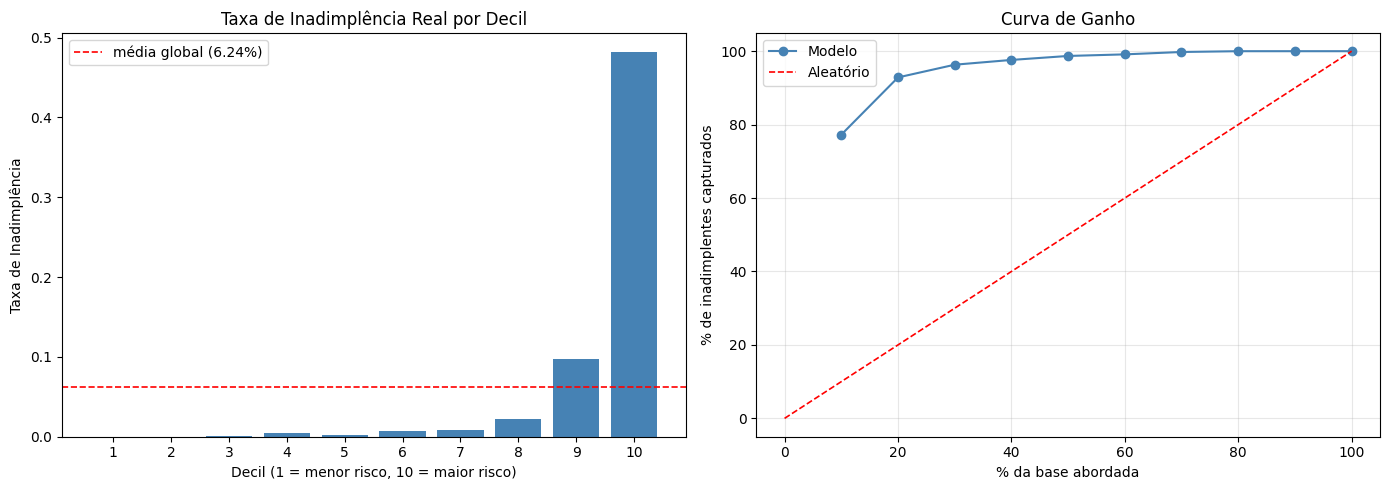

Total inadimplentes na validação: 462
Abordando 10% da base (decil 10): captura 77.3% dos inadimplentes
Abordando 20% da base (decis 9-10): captura 92.9% dos inadimplentes


In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: taxa real por decil
axes[0].bar(calib_decil['decil'], calib_decil['taxa_real'], color='steelblue')
axes[0].axhline(y_valid.mean(), color='red', linestyle='--',
                linewidth=1.2, label=f'média global ({y_valid.mean():.2%})')
axes[0].set_title('Taxa de Inadimplência Real por Decil')
axes[0].set_xlabel('Decil (1 = menor risco, 10 = maior risco)')
axes[0].set_ylabel('Taxa de Inadimplência')
axes[0].set_xticks(range(1, 11))
axes[0].legend()

# --- Gráfico 2: % de inadimplentes capturados acumulado (curva de ganho)
calib_decil_desc = calib_decil.sort_values('decil', ascending=False)
calib_decil_desc['inad_acum'] = calib_decil_desc['n_inad'].cumsum()
calib_decil_desc['pct_inad_capturado'] = (calib_decil_desc['inad_acum'] /
                                           calib_decil_desc['n_inad'].sum())
calib_decil_desc['pct_base'] = (calib_decil_desc['n'].cumsum() /
                                 calib_decil_desc['n'].sum())

axes[1].plot(calib_decil_desc['pct_base'] * 100,
             calib_decil_desc['pct_inad_capturado'] * 100,
             marker='o', color='steelblue', label='Modelo')
axes[1].plot([0, 100], [0, 100], 'r--', linewidth=1.2, label='Aleatório')
axes[1].set_title('Curva de Ganho')
axes[1].set_xlabel('% da base abordada')
axes[1].set_ylabel('% de inadimplentes capturados')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Números chave para o negócio
total_inad = calib_decil['n_inad'].sum()
top1_inad  = calib_decil[calib_decil['decil'] == 10]['n_inad'].values[0]
top2_inad  = calib_decil[calib_decil['decil'] >= 9]['n_inad'].sum()

print(f"Total inadimplentes na validação: {total_inad}")
print(f"Abordando 10% da base (decil 10): captura {top1_inad/total_inad:.1%} dos inadimplentes")
print(f"Abordando 20% da base (decis 9-10): captura {top2_inad/total_inad:.1%} dos inadimplentes")

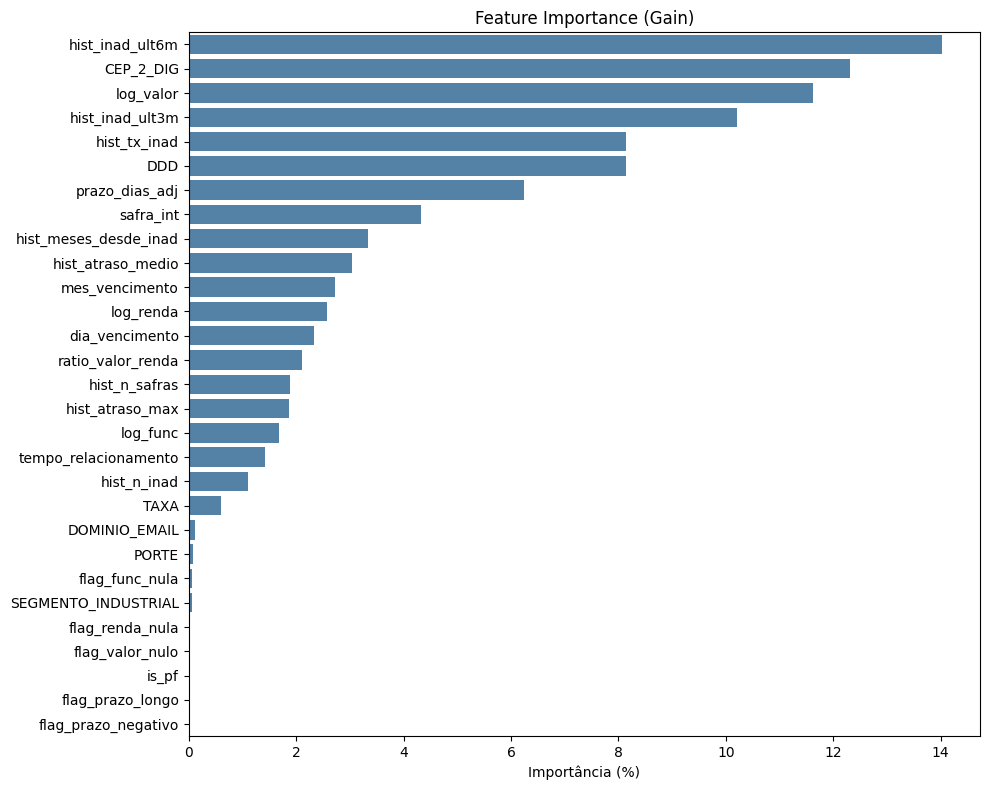

              feature  importance  importance_pct
      hist_inad_ult6m   156859.18           14.03
            CEP_2_DIG   137542.06           12.30
            log_valor   129938.55           11.62
      hist_inad_ult3m   114107.00           10.21
         hist_tx_inad    91076.08            8.15
                  DDD    90961.25            8.14
       prazo_dias_adj    69847.16            6.25
            safra_int    48296.98            4.32
hist_meses_desde_inad    37313.25            3.34
    hist_atraso_medio    33994.53            3.04
       mes_vencimento    30475.81            2.73
            log_renda    28743.22            2.57
       dia_vencimento    26020.45            2.33
    ratio_valor_renda    23489.56            2.10
        hist_n_safras    21080.49            1.89
      hist_atraso_max    20761.69            1.86
             log_func    18823.53            1.68
 tempo_relacionamento    15860.44            1.42
          hist_n_inad    12268.88            1.10


In [124]:
fi = pd.DataFrame({
    'feature'   : model.feature_name(),
    'importance': model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False).reset_index(drop=True)

fi['importance_pct'] = fi['importance'] / fi['importance'].sum() * 100

plt.figure(figsize=(10, 8))
sns.barplot(data=fi, x='importance_pct', y='feature', color='steelblue')
plt.title('Feature Importance (Gain)')
plt.xlabel('Importância (%)')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(fi.round(2).to_string(index=False))

In [125]:
prob_teste = model.predict(X_teste)

submissao = df_teste[['ID_CLIENTE', 'SAFRA_REF']].copy()
submissao['PROBABILIDADE_INADIMPLENCIA'] = prob_teste

print(f"Shape: {submissao.shape}")
print(f"\nDistribuição das probabilidades:")
print(submissao['PROBABILIDADE_INADIMPLENCIA'].describe().round(4))
print(f"\nPrimeiras linhas:")
print(submissao.head(10).to_string(index=False))

Shape: (12275, 3)

Distribuição das probabilidades:
count   12275.00
mean        0.09
std         0.20
min         0.00
25%         0.01
50%         0.01
75%         0.04
max         0.98
Name: PROBABILIDADE_INADIMPLENCIA, dtype: float64

Primeiras linhas:
         ID_CLIENTE SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
5058298901476893676   2021-07                         0.01
 274692171162531764   2021-07                         0.08
 274692171162531764   2021-07                         0.12
 274692171162531764   2021-07                         0.16
 465309249432033993   2021-07                         0.02
 465309249432033993   2021-07                         0.01
 465309249432033993   2021-07                         0.01
 465309249432033993   2021-07                         0.01
5883155883105348987   2021-07                         0.02
5883155883105348987   2021-07                         0.02


## Modelagem

### Algoritmo escolhido — LightGBM
Padrão da indústria para scoring de crédito. Escolhido por:
- Lida nativamente com NaN e variáveis categóricas
- Robusto a dados desbalanceados via `is_unbalance=True`
- Rápido, interpretável via feature importance
- Recomendado para problemas onde será necessário explicar as decisões

### Parâmetros principais
| Parâmetro | Valor | Justificativa |
|---|---|---|
| `objective` | binary | Problema de classificação binária |
| `metric` | auc | Métrica adequada para dados desbalanceados |
| `learning_rate` | 0.05 | Aprendizado lento e estável |
| `num_leaves` | 63 | Controla complexidade da árvore |
| `min_child_samples` | 30 | Evita overfitting em folhas com poucos dados |
| `feature_fraction` | 0.8 | Subsample de features por árvore — regularização |
| `bagging_fraction` | 0.8 | Subsample de linhas por árvore — regularização |
| `is_unbalance` | True | Trata desbalanceamento de 7% de positivos |
| `seed` | 42 | Reprodutibilidade |

### Treinamento
- Early stopping com 50 rodadas de paciência
- Melhor iteração: **131**
- Parou antes das 1000 rodadas — regularização funcionando

### Métricas de Avaliação (validação OOT)
| Métrica | Valor | Interpretação |
|---|---|---|
| AUC-ROC treino | 0.9895 | — |
| AUC-ROC validação | 0.9542 | Excelente — modelos de crédito em produção ficam entre 0.70-0.85 |
| Average Precision | 0.6670 | Bom — penaliza falsos positivos, mais conservadora que AUC |
| KS Statistic | 0.7877 | Excelente — KS > 0.40 já é considerado bom em crédito |

Diferença AUC treino/validação de ~0.035 — generalização saudável, sem overfitting severo.

### Calibração por Decil
| Decil | Registros | Inadimplentes | Taxa Real |
|---|---|---|---|
| 1-7 | 5.181 | 17 | ~0% |
| 8 | 740 | 16 | 2% |
| 9 | 740 | 72 | 10% |
| 10 | 741 | 357 | 48% |

### Valor para o Negócio — Curva de Ganho
- Abordando **10% da base** (decil 10) → captura **77.3%** dos inadimplentes
- Abordando **20% da base** (decis 9-10) → captura **92.9%** dos inadimplentes

Sem o modelo, seria necessário abordar 100% da base para o mesmo resultado.

### Feature Importance (Top 10)
| Feature | Importância | Grupo |
|---|---|---|
| `hist_inad_ult6m` | 14.0% | Histórico |
| `CEP_2_DIG` | 12.3% | Cadastral |
| `log_valor` | 11.6% | Cobrança |
| `hist_inad_ult3m` | 10.2% | Histórico |
| `hist_tx_inad` | 8.2% | Histórico |
| `DDD` | 8.1% | Cadastral |
| `prazo_dias_adj` | 6.3% | Cobrança |
| `safra_int` | 4.3% | Temporal |
| `hist_meses_desde_inad` | 3.3% | Histórico |
| `hist_atraso_medio` | 3.0% | Histórico |

**Observação:** `CEP_2_DIG` e `DDD` têm alta importância mas merecem
atenção em produção — mudanças na distribuição geográfica dos clientes
podem degradar o modelo mais rapidamente que features comportamentais.

In [126]:
submissao.to_csv('submissao_case.csv', index=False)

df_check = pd.read_csv('submissao_case.csv')

print("=== Validação do arquivo de submissão ===")
print(f"Shape: {df_check.shape}")
print(f"Colunas: {df_check.columns.tolist()}")
print(f"Nulos: {df_check.isnull().sum().to_dict()}")
print(f"Probabilidades fora de [0,1]: {((df_check['PROBABILIDADE_INADIMPLENCIA'] < 0) | (df_check['PROBABILIDADE_INADIMPLENCIA'] > 1)).sum()}")
print(f"Duplicatas (ID_CLIENTE + SAFRA_REF): {df_check.duplicated(['ID_CLIENTE','SAFRA_REF']).sum()}")
print(f"\nPrimeiras linhas:")
print(df_check.head(5).to_string(index=False))

=== Validação do arquivo de submissão ===
Shape: (12275, 3)
Colunas: ['ID_CLIENTE', 'SAFRA_REF', 'PROBABILIDADE_INADIMPLENCIA']
Nulos: {'ID_CLIENTE': 0, 'SAFRA_REF': 0, 'PROBABILIDADE_INADIMPLENCIA': 0}
Probabilidades fora de [0,1]: 0
Duplicatas (ID_CLIENTE + SAFRA_REF): 8836

Primeiras linhas:
         ID_CLIENTE SAFRA_REF  PROBABILIDADE_INADIMPLENCIA
5058298901476893676   2021-07                         0.01
 274692171162531764   2021-07                         0.08
 274692171162531764   2021-07                         0.12
 274692171162531764   2021-07                         0.16
 465309249432033993   2021-07                         0.02


# INTELIGÊNCIA DE NEGÓCIO

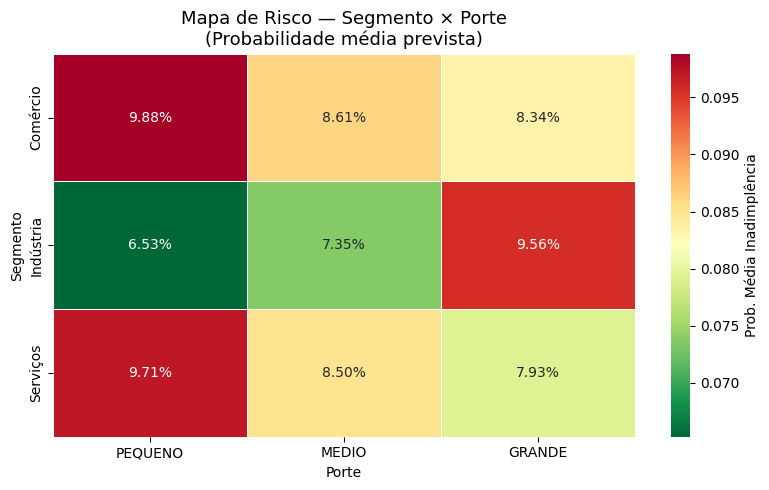

Probabilidade média por grupo:
PORTE                PEQUENO  MEDIO  GRANDE
SEGMENTO_INDUSTRIAL                        
Comércio                0.10   0.09    0.08
Indústria               0.07   0.07    0.10
Serviços                0.10   0.09    0.08


In [127]:
df_risco = df_teste.copy()
df_risco['PROBABILIDADE'] = prob_teste

heatmap_data = (df_risco[
    (df_risco['SEGMENTO_INDUSTRIAL'] != 'DESCONHECIDO') &
    (df_risco['PORTE'] != 'DESCONHECIDO')]
    .groupby(['SEGMENTO_INDUSTRIAL', 'PORTE'])['PROBABILIDADE']
    .mean()
    .unstack()
)

heatmap_data = heatmap_data[['PEQUENO', 'MEDIO', 'GRANDE']]

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2%', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Prob. Média Inadimplência'})
plt.title('Mapa de Risco — Segmento × Porte\n(Probabilidade média prevista)',
          fontsize=13)
plt.xlabel('Porte')
plt.ylabel('Segmento')
plt.tight_layout()
plt.show()

print("Probabilidade média por grupo:")
print(heatmap_data.round(4).to_string())

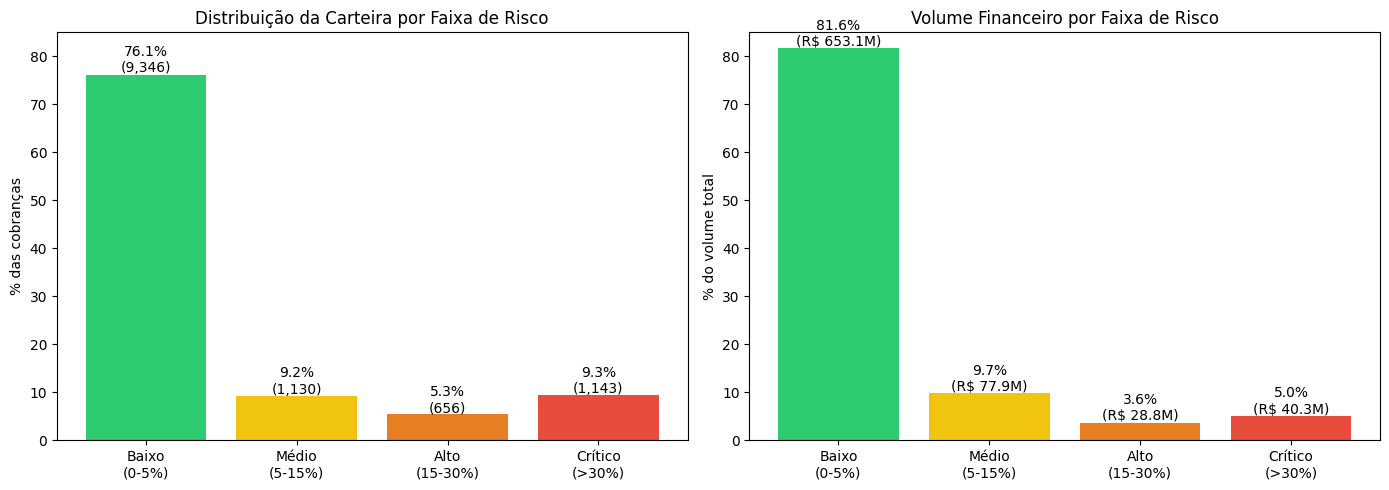

    faixa_risco  n_cobranças  pct_cobranças  volume_financeiro  pct_volume
  Baixo\n(0-5%)         9346           0.76       653149616.20        0.82
 Médio\n(5-15%)         1130           0.09        77851236.49        0.10
 Alto\n(15-30%)          656           0.05        28776559.14        0.04
Crítico\n(>30%)         1143           0.09        40308880.31        0.05


In [129]:
df_risco['faixa_risco'] = pd.cut(
    df_risco['PROBABILIDADE'],
    bins=[0, 0.05, 0.15, 0.30, 1.0],
    labels=['Baixo\n(0-5%)', 'Médio\n(5-15%)',
            'Alto\n(15-30%)', 'Crítico\n(>30%)']
)

dist_risco = (df_risco.groupby('faixa_risco', observed=True)
              .agg(
                  n_cobranças     = ('PROBABILIDADE', 'count'),
                  prob_media      = ('PROBABILIDADE', 'mean'),
                  volume_financeiro = ('VALOR_A_PAGAR', 'sum')
              )
              .reset_index())

dist_risco['pct_cobranças']  = dist_risco['n_cobranças'] / dist_risco['n_cobranças'].sum()
dist_risco['pct_volume']     = dist_risco['volume_financeiro'] / dist_risco['volume_financeiro'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

axes[0].bar(dist_risco['faixa_risco'], dist_risco['pct_cobranças'] * 100, color=cores)
for i, row in dist_risco.iterrows():
    axes[0].text(i, row['pct_cobranças'] * 100 + 0.5,
                 f"{row['pct_cobranças']:.1%}\n({row['n_cobranças']:,})",
                 ha='center', fontsize=10)
axes[0].set_title('Distribuição da Carteira por Faixa de Risco')
axes[0].set_ylabel('% das cobranças')
axes[0].set_ylim(0, 85)

axes[1].bar(dist_risco['faixa_risco'], dist_risco['pct_volume'] * 100, color=cores)
for i, row in dist_risco.iterrows():
    axes[1].text(i, row['pct_volume'] * 100 + 0.5,
                 f"{row['pct_volume']:.1%}\n(R$ {row['volume_financeiro']/1e6:.1f}M)",
                 ha='center', fontsize=10)
axes[1].set_title('Volume Financeiro por Faixa de Risco')
axes[1].set_ylabel('% do volume total')
axes[1].set_ylim(0, 85)

plt.tight_layout()
plt.show()

print(dist_risco[['faixa_risco','n_cobranças','pct_cobranças',
                   'volume_financeiro','pct_volume']].round(4).to_string(index=False))

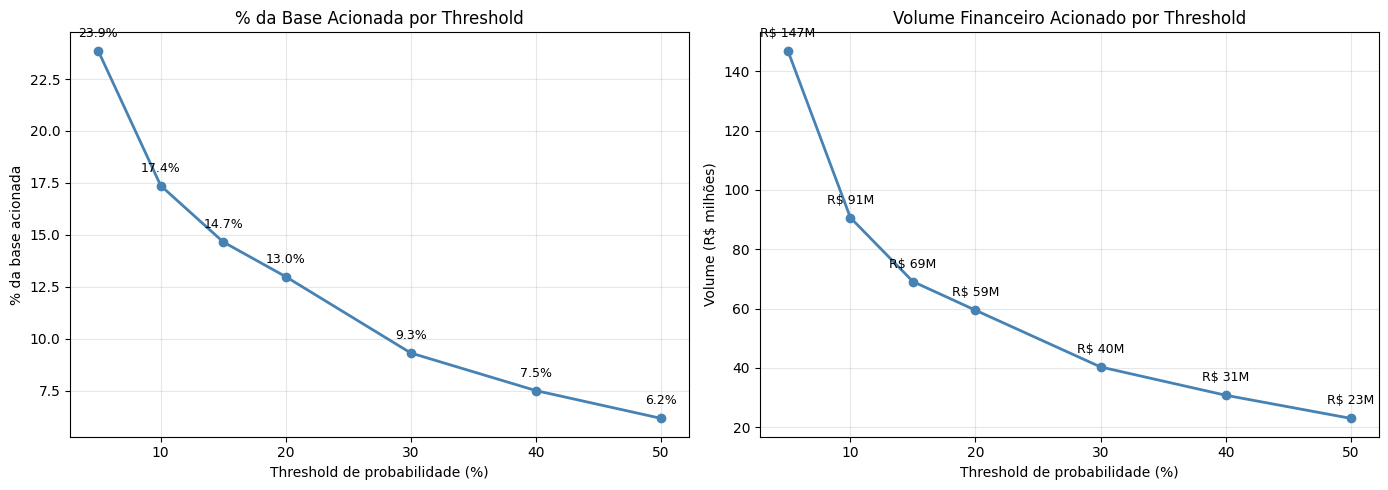

 threshold  n_acionados  pct_base  volume_acionado  pct_volume
      0.05         2929      0.24     146936675.94        0.18
      0.10         2132      0.17      90647037.77        0.11
      0.15         1799      0.15      69085439.45        0.09
      0.20         1594      0.13      59436156.93        0.07
      0.30         1143      0.09      40308880.31        0.05
      0.40          921      0.07      30774394.96        0.04
      0.50          757      0.06      22977124.35        0.03


In [130]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

regua = []
total_cobr = len(prob_teste)
total_volume = df_risco['VALOR_A_PAGAR'].sum()

for t in thresholds:
    acionados = df_risco[df_risco['PROBABILIDADE'] >= t]
    regua.append({
        'threshold'        : t,
        'n_acionados'      : len(acionados),
        'pct_base'         : len(acionados) / total_cobr,
        'volume_acionado'  : acionados['VALOR_A_PAGAR'].sum(),
        'pct_volume'       : acionados['VALOR_A_PAGAR'].sum() / total_volume,
    })

df_regua = pd.DataFrame(regua)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_regua['threshold'] * 100, df_regua['pct_base'] * 100,
             marker='o', color='steelblue', linewidth=2)
for _, row in df_regua.iterrows():
    axes[0].annotate(f"{row['pct_base']:.1%}",
                     (row['threshold'] * 100, row['pct_base'] * 100),
                     textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
axes[0].set_title('% da Base Acionada por Threshold')
axes[0].set_xlabel('Threshold de probabilidade (%)')
axes[0].set_ylabel('% da base acionada')
axes[0].grid(alpha=0.3)

axes[1].plot(df_regua['threshold'] * 100, df_regua['volume_acionado'] / 1e6,
             marker='o', color='steelblue', linewidth=2)
for _, row in df_regua.iterrows():
    axes[1].annotate(f"R$ {row['volume_acionado']/1e6:.0f}M",
                     (row['threshold'] * 100, row['volume_acionado'] / 1e6),
                     textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
axes[1].set_title('Volume Financeiro Acionado por Threshold')
axes[1].set_xlabel('Threshold de probabilidade (%)')
axes[1].set_ylabel('Volume (R$ milhões)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df_regua.round(4).to_string(index=False))

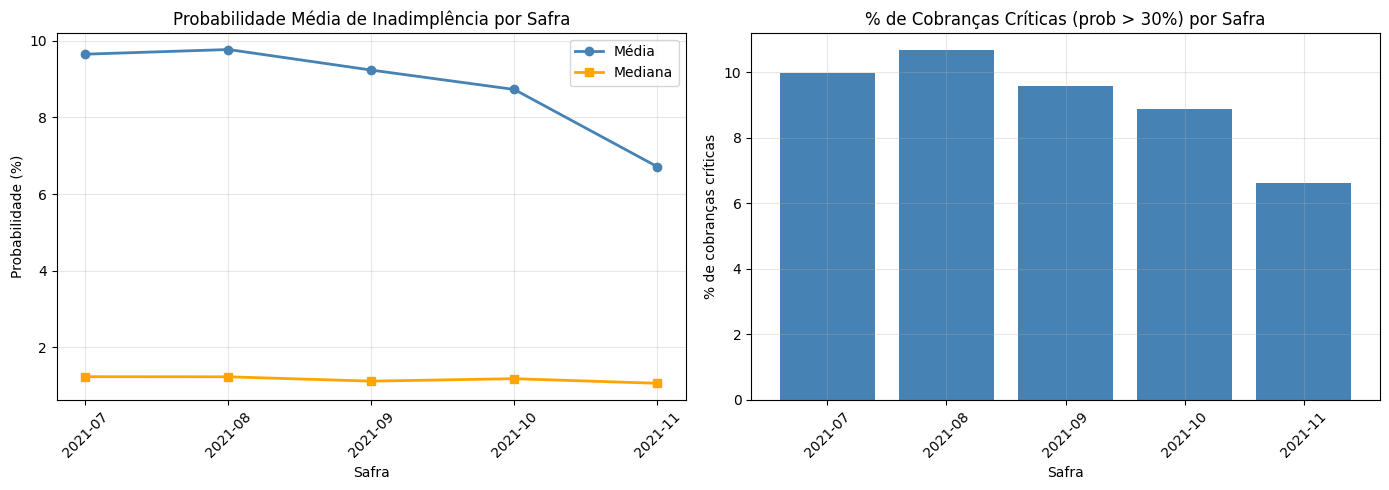

SAFRA_REF  prob_media  prob_mediana  n_cobranças  pct_critico
  2021-07        0.10          0.01         2529         0.10
  2021-08        0.10          0.01         2654         0.11
  2021-09        0.09          0.01         2667         0.10
  2021-10        0.09          0.01         2673         0.09
  2021-11        0.07          0.01         1752         0.07


In [131]:
evolucao = (df_risco.groupby('SAFRA_REF')
            .agg(
                prob_media    = ('PROBABILIDADE', 'mean'),
                prob_mediana  = ('PROBABILIDADE', 'median'),
                n_cobranças   = ('PROBABILIDADE', 'count'),
                pct_critico   = ('PROBABILIDADE', lambda x: (x >= 0.30).mean())
            )
            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(evolucao['SAFRA_REF'], evolucao['prob_media'] * 100,
             marker='o', color='steelblue', linewidth=2, label='Média')
axes[0].plot(evolucao['SAFRA_REF'], evolucao['prob_mediana'] * 100,
             marker='s', color='orange', linewidth=2, label='Mediana')
axes[0].set_title('Probabilidade Média de Inadimplência por Safra')
axes[0].set_xlabel('Safra')
axes[0].set_ylabel('Probabilidade (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(evolucao['SAFRA_REF'], evolucao['pct_critico'] * 100, color='steelblue')
axes[1].set_title('% de Cobranças Críticas (prob > 30%) por Safra')
axes[1].set_xlabel('Safra')
axes[1].set_ylabel('% de cobranças críticas')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(evolucao.round(4).to_string(index=False))

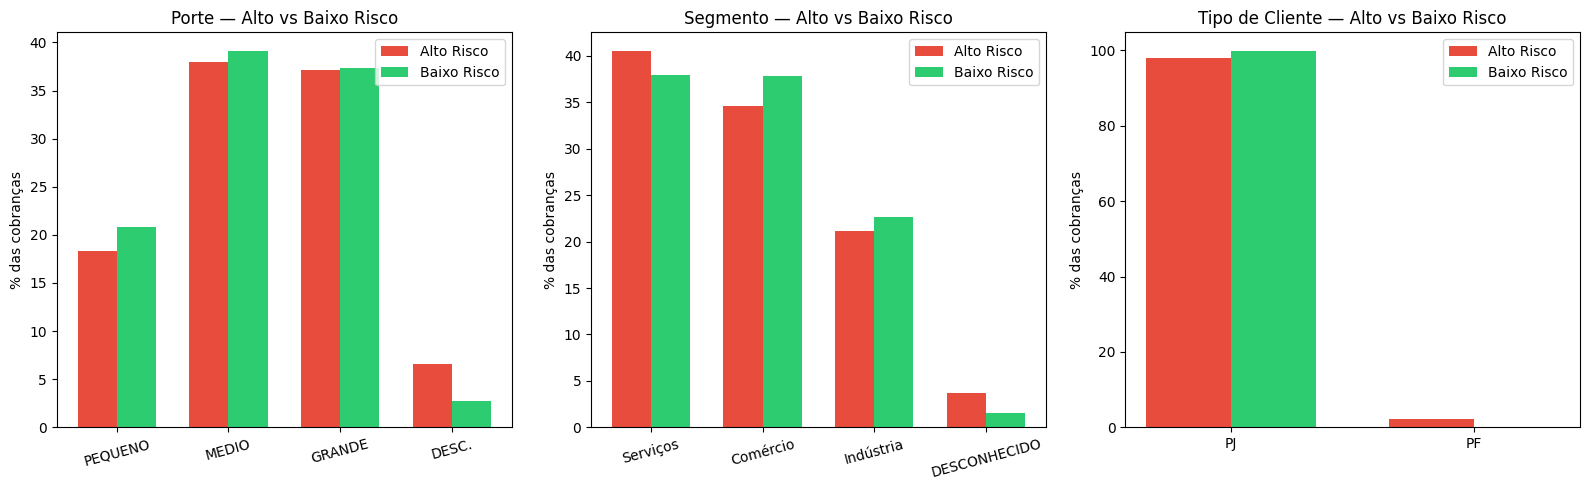

=== Perfil Alto Risco (prob >= 30%) ===
Total cobranças : 1,143
Volume financeiro: R$ 40.3M

Porte:
PORTE
PEQUENO        0.18
MEDIO          0.38
GRANDE         0.37
DESCONHECIDO   0.07
Name: proportion, dtype: float64

Segmento:
SEGMENTO_INDUSTRIAL
Serviços       0.41
Comércio       0.35
Indústria      0.21
DESCONHECIDO   0.04
Name: proportion, dtype: float64

PF vs PJ:
is_pf
PJ   0.98
PF   0.02
Name: proportion, dtype: float64


In [133]:
alto_risco = df_risco[df_risco['PROBABILIDADE'] >= 0.30].copy()
baixo_risco = df_risco[df_risco['PROBABILIDADE'] < 0.30].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

porte_ar = (alto_risco['PORTE'].value_counts(normalize=True)
            .reindex(['PEQUENO','MEDIO','GRANDE','DESCONHECIDO']).fillna(0))
porte_br = (baixo_risco['PORTE'].value_counts(normalize=True)
            .reindex(['PEQUENO','MEDIO','GRANDE','DESCONHECIDO']).fillna(0))

x = np.arange(len(porte_ar))
width = 0.35
axes[0].bar(x - width/2, porte_ar * 100, width, label='Alto Risco', color='#e74c3c')
axes[0].bar(x + width/2, porte_br * 100, width, label='Baixo Risco', color='#2ecc71')
axes[0].set_title('Porte — Alto vs Baixo Risco')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['PEQUENO','MEDIO','GRANDE','DESC.'], rotation=15)
axes[0].set_ylabel('% das cobranças')
axes[0].legend()

seg_ar = (alto_risco['SEGMENTO_INDUSTRIAL'].value_counts(normalize=True))
seg_br = (baixo_risco['SEGMENTO_INDUSTRIAL'].value_counts(normalize=True))
categorias = seg_ar.index.tolist()
x = np.arange(len(categorias))
axes[1].bar(x - width/2, seg_ar * 100, width, label='Alto Risco', color='#e74c3c')
axes[1].bar(x + width/2, seg_br.reindex(categorias).fillna(0) * 100,
            width, label='Baixo Risco', color='#2ecc71')
axes[1].set_title('Segmento — Alto vs Baixo Risco')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categorias, rotation=15)
axes[1].set_ylabel('% das cobranças')
axes[1].legend()

tipo_ar = alto_risco['is_pf'].map({1:'PF', 0:'PJ'}).value_counts(normalize=True)
tipo_br = baixo_risco['is_pf'].map({1:'PF', 0:'PJ'}).value_counts(normalize=True)
categorias = ['PJ', 'PF']
x = np.arange(len(categorias))
axes[2].bar(x - width/2,
            [tipo_ar.get(c, 0) * 100 for c in categorias],
            width, label='Alto Risco', color='#e74c3c')
axes[2].bar(x + width/2,
            [tipo_br.get(c, 0) * 100 for c in categorias],
            width, label='Baixo Risco', color='#2ecc71')
axes[2].set_title('Tipo de Cliente — Alto vs Baixo Risco')
axes[2].set_xticks(x)
axes[2].set_xticklabels(categorias)
axes[2].set_ylabel('% das cobranças')
axes[2].legend()

plt.tight_layout()
plt.show()

# Números
print("=== Perfil Alto Risco (prob >= 30%) ===")
print(f"Total cobranças : {len(alto_risco):,}")
print(f"Volume financeiro: R$ {alto_risco['VALOR_A_PAGAR'].sum()/1e6:.1f}M")
print(f"\nPorte:\n{porte_ar.round(3)}")
print(f"\nSegmento:\n{seg_ar.round(3)}")
print(f"\nPF vs PJ:\n{tipo_ar.round(3)}")

## Inteligência de Negócio

### Visão Geral da Carteira de Teste
- **12.275 cobranças** em 5 safras (jul-nov/2021)
- **Volume total**: R$ 800M+
- **Probabilidade média prevista**: 9%

---

### 1. Mapa de Risco — Segmento × Porte

**Grupos de maior risco:**
- **Comércio Pequeno (9.88%)** e **Serviços Pequeno (9.71%)** — combinação de
  porte reduzido com receita irregular eleva o risco
- **Indústria Grande (9.56%)** — resultado contraintuitivo. Grandes indústrias
  superam pequenas (6.53%) em risco, possivelmente por ciclos de pagamento
  mais longos e processos de aprovação mais burocráticos

**Recomendação:** política de crédito diferenciada por célula —
atenção redobrada para Comércio Pequeno, Serviços Pequeno e Indústria Grande.

---

### 2. Distribuição da Carteira por Faixa de Risco

| Faixa | Cobranças | % da base | Volume | % do volume |
|---|---|---|---|---|
| Baixo (0-5%) | 9.346 | 76.1% | R$ 653M | 81.6% |
| Médio (5-15%) | 1.130 | 9.2% | R$ 78M | 9.7% |
| Alto (15-30%) | 656 | 5.3% | R$ 29M | 3.6% |
| Crítico (>30%) | 1.143 | 9.3% | R$ 40M | 5.0% |

**Insight:** 76% da base tem risco baixo e pode receber tratamento padrão
sem ação proativa. Os 9.3% críticos concentram R$ 40M em volume de risco.

---

### 3. Régua de Acionamento

| Threshold | Clientes acionados | % da base | Volume protegido |
|---|---|---|---|
| 5% | 2.929 | 23.9% | R$ 147M |
| 10% | 2.132 | 17.4% | R$ 91M |
| 15% | 1.799 | 14.7% | R$ 69M |
| 20% | 1.594 | 13.0% | R$ 59M |
| 30% | 1.143 | 9.3% | R$ 40M |
| 50% | 757 | 6.2% | R$ 23M |

**Recomendação operacional:** threshold de 15-20% como ponto de equilíbrio —
aciona ~14% da base e protege R$ 59-69M em volume, sem sobrecarregar
a equipe de cobrança com falsos positivos.

---

### 4. Evolução do Risco por Safra (jul-nov/2021)

| Safra | Prob. Média | % Críticos |
|---|---|---|
| 2021-07 | 10% | 10% |
| 2021-08 | 10% | 11% |
| 2021-09 | 9% | 10% |
| 2021-10 | 9% | 9% |
| 2021-11 | 7% | 7% |

**Tendência positiva:** risco médio caindo de 10% em jul/2021 para 7% em
nov/2021. A proporção de cobranças críticas também reduz consistentemente.
Indica melhora no perfil de pagamento da carteira ao longo do período.

---

### 5. Perfil dos Clientes de Alto Risco (prob ≥ 30%)

- **1.143 cobranças** em risco crítico | **R$ 40.3M** em volume
- **98% são PJ** — pessoas jurídicas dominam o risco crítico absoluto,
  apesar de PF ter taxa individual maior (volume pequeno de PF na carteira)
- **Serviços (41%)** e **Comércio (35%)** concentram 76% das cobranças críticas
- Distribuição de porte similar entre alto e baixo risco — porte sozinho
  não é discriminante suficiente para identificar clientes críticos

**Conclusão:** o perfil típico do cliente crítico é uma **empresa de médio
ou grande porte do setor de Serviços ou Comércio com histórico recente
de atrasos** — o comportamento passado (capturado pelas features históricas)
é o principal diferenciador, não o perfil cadastral isolado.

---

### Resumo Executivo

> Abordando apenas **20% da base** com maior probabilidade prevista,
> a equipe de cobrança captura **92.9% dos inadimplentes** e protege
> aproximadamente **R$ 59M** em volume financeiro — com uma fração
> do esforço que seria necessário sem o modelo.